# TikTok Video Sampling Strategy v2 — BPC-Aware Quota-Constrained Sampling

**Status:** Proof-of-concept backtest of `tiktok-sampling-strategy-v2-proposal.md`.
**Scope:** 4 markets (ID/MY/PH/TH) x 2 content types (Beauty / Non-Beauty),
under a fixed business quota (50% ID / 80% Beauty), comparing **7 sampling
methods** on **7 coverage metrics**, all on equal budget (2,000 videos).

This notebook implements the full design spec end to end:

1. Build the effective video universe and the video&harr;hashtag bridge table.
2. Assign every video to one of 8 quota cells (country x Beauty/Non-Beauty).
3. Allocate the fixed 2,000-video budget across the 8 cells.
4. Run all 7 sampling methods independently inside each cell.
5. Compute 7 coverage metrics per cell per method, then aggregate to a scorecard.
6. Compare methods via radar charts, heatmaps, and supplementary diagnostics
   (pairwise overlap, lift vs. random baseline, growth cross-check).

> Generated by `notebook/build_notebook_v2.py`. To change the notebook
> (including this cell), edit the builder and re-run it - never hand-edit
> the `.ipynb` file directly.

## 1. Setup

**Color system.** Two different color jobs are used, on purpose:

- **Magnitude / heatmap encodings** (correlation, per-cell detail, fill rate)
  use a single blue sequential ramp, light -> dark (Paragon brand).
- **Method identity** (radar, per-metric ranking, overlap, lift, growth
  cross-check) uses a **fixed 8-hue categorical palette, led by blue**, so
  the 6 rule-based methods stay visually distinct from each other even when
  their lines cross or overlap (six shades of one hue read as near-identical
  once lines overlap - a real hue difference doesn't). **M7 (Random
  baseline)** is kept in a distinct neutral slate gray throughout, since it
  is a statistical control, not a candidate method.
- Every chart still carries direct value labels as a secondary channel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from IPython.display import Markdown, display


def insight(text: str) -> None:
    '''Render a data-driven takeaway as formatted markdown instead of a plain print.'''
    display(Markdown(f"**Insight.** {text}"))

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# --- Blue sequential ramp (Paragon brand) ---------------------------------
BLUE_RAMP = {
    100: "#cde2fb", 150: "#b7d3f6", 200: "#9ec5f4", 250: "#86b6ef",
    300: "#6da7ec", 350: "#5598e7", 400: "#3987e5", 450: "#2a78d6",
    500: "#256abf", 550: "#1c5cab", 600: "#184f95", 650: "#104281",
    700: "#0d366b",
}
BLUE_CMAP = LinearSegmentedColormap.from_list("paragon_blue", [BLUE_RAMP[100], BLUE_RAMP[700]])

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"
GOOD = "#0ca30c"
CRITICAL = "#d03b3b"
RANDOM_GRAY = "#726f68"

METHOD_ORDER = ["M1 Broad (Rank Position)", "M2 Narrow (Ranking)", "M3 Top-K (Virality)",
                "M4 Top-K (Trending)", "M5 Top-K (Avg Score)", "M7 Random Baseline"]
METHOD_KEYS = ["M1", "M2", "M3", "M4", "M5", "M7"]

# Categorical identity for the 6 methods. Overlapping lines (radar chart) need real hue
# separation, not lightness steps of one hue - shades of blue read as near-identical once
# lines cross. This is the validated 8-hue categorical palette (fixed CVD-safe order),
# still led by blue, with M7 Random kept in neutral gray as the odd-one-out control.
CATEGORICAL = {"blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
               "violet": "#4a3aa7", "red": "#e34948"}
METHOD_COLOR = dict(zip(METHOD_ORDER, [
    CATEGORICAL["blue"], CATEGORICAL["aqua"], CATEGORICAL["yellow"], CATEGORICAL["green"],
    CATEGORICAL["violet"], RANDOM_GRAY,
]))
KEY_TO_LABEL = dict(zip(METHOD_KEYS, METHOD_ORDER))

CORE_METRIC_LABELS = ["Coverage\nRatio", "Breadth\nCoverage", "Category\nBalance", "Creator\nDiversity",
                      "Trending\nRatio", "Virality\nRatio", "Long-tail\nCoverage"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "grid.color": GRIDLINE,
    "text.color": INK_PRIMARY, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
})

PINNED_DATE = "2026-06-27"
COUNTRIES = ["ID", "MY", "PH", "TH"]
TYPES = ["BEAUTY", "NON BEAUTY"]
COUNTRY_SHARE = {"ID": 0.5, "MY": 1 / 6, "PH": 1 / 6, "TH": 1 / 6}
TYPE_SHARE = {"BEAUTY": 0.8, "NON BEAUTY": 0.2}
LONG_TAIL_PERCENTILE = 0.5

BUDGET = 2000
COST_PER_VIDEO = 200  # Rupiah
RNG_SEED = 42

## 2. Load & Clean Data

Three source files (Section 2 of the proposal):

| File | Role |
|---|---|
| `tiktok-video_combined_score_20260627.csv` | Video universe + scores |
| `hashtag_to_video.csv` | Video&harr;hashtag membership (union across all 9 extract dates) |
| `hashtag_overview.csv` | Hashtag ranking source (pinned to a single date: 2026-06-27) |

Two data-quality fixes are applied here, both confirmed during the design
discussion:

1. `hashtag_to_video.csv`'s `VIDEO_ID` column has malformed rows that corrupt
   dtype inference - read as string, drop malformed rows, cast to `int64`.
2. `hashtag_overview.csv` can have a hashtag listed under more than one
   category on the same day (~3.7% of hashtags) - resolved by keeping the
   row with the best (lowest) `RANK_POSITION_NUMBER`.

In [2]:
DATA = "../data"

video = pd.read_csv(f"{DATA}/processed/tiktok-video_combined_score_20260627.csv")

h2v = pd.read_csv(f"{DATA}/hashtag/hashtag_to_video.csv", dtype=str)
h2v = h2v[h2v["VIDEO_ID"].str.len().fillna(0) > 5].copy()
h2v["VIDEO_ID"] = h2v["VIDEO_ID"].astype("int64")
h2v["hkey"] = list(zip(h2v["HASHTAG_ID"], h2v["COUNTRY_CODE"]))
h2v = h2v.drop_duplicates(["VIDEO_ID", "hkey"])

ho = pd.read_csv(f"{DATA}/hashtag/hashtag_overview.csv", dtype=str)
ho_pinned = ho[ho["DATA_EXTRACT_DATE"] == PINNED_DATE].copy()
for c in ["RANK_POSITION_NUMBER", "RANKING", "VIEW_COUNT", "POST_COUNT"]:
    ho_pinned[c] = pd.to_numeric(ho_pinned[c], errors="coerce")
ho_pinned["hkey"] = list(zip(ho_pinned["HASHTAG_ID"], ho_pinned["COUNTRY_CODE"]))
ho_pinned = ho_pinned.sort_values("RANK_POSITION_NUMBER").drop_duplicates("hkey", keep="first")

# Category rank ceiling per (country, category) -> needed later for the long-tail percentile metric
ho_pinned["cat_max_rank"] = ho_pinned.groupby(["COUNTRY_CODE", "CATEGORY_NAME"])["RANK_POSITION_NUMBER"].transform("max")
ho_pinned["rank_percentile"] = ho_pinned["RANK_POSITION_NUMBER"] / ho_pinned["cat_max_rank"]

N_CAT_BY_TYPE = ho_pinned.groupby("HASHTAG_TYPE")["CATEGORY_NAME"].nunique().to_dict()

print(f"video universe (raw)      : {video.video_id.nunique():>7,}")
print(f"hashtag_to_video (union)  : {h2v.shape[0]:>7,} rows, {h2v['hkey'].nunique():>7,} unique hashtag x country")
print(f"hashtag_overview @ {PINNED_DATE}: {ho_pinned.shape[0]:>7,} hashtag x country rows")
print(f"categories by type        : {N_CAT_BY_TYPE}")

video universe (raw)      :  13,143


hashtag_to_video (union)  : 809,858 rows,  49,202 unique hashtag x country
hashtag_overview @ 2026-06-27:  16,174 hashtag x country rows
categories by type        : {'BEAUTY': 4, 'NON BEAUTY': 57}


## 3. Bridge Table & Effective Universe

The `edges` table links video &harr; hashtag, carrying the hashtag's ranking
attributes (`RANK_POSITION_NUMBER`, `RANKING`, `HASHTAG_TYPE`, `CATEGORY_NAME`,
`VIEW_COUNT`, `rank_percentile`) needed by the sampling methods and metrics.

Because ranking is pinned to a single date, a video is only "visible" here if
at least one of its hashtags is present in `hashtag_overview` on 2026-06-27.
As found during design: this excludes **~22% of the raw universe** - accepted
as a documented limitation (Section 8 of the proposal) rather than patched
with a fallback date-window.

In [3]:
edges = h2v[h2v["VIDEO_ID"].isin(video["video_id"])][["VIDEO_ID", "hkey"]].drop_duplicates()
edges = edges.merge(
    ho_pinned[["hkey", "HASHTAG_ID", "HASHTAG_NAME", "COUNTRY_CODE", "HASHTAG_TYPE", "CATEGORY_NAME",
               "RANK_POSITION_NUMBER", "RANKING", "VIEW_COUNT", "rank_percentile"]],
    on="hkey",
)
edges = edges.rename(columns={"VIEW_COUNT": "hashtag_view_count"})

effective_ids = edges["VIDEO_ID"].unique()
video_eff = video[video["video_id"].isin(effective_ids)].copy()
excluded_n = video["video_id"].nunique() - video_eff["video_id"].nunique()

print(f"edges                      : {edges.shape[0]:>7,} rows")
print(f"effective universe         : {video_eff.video_id.nunique():>7,} / {video.video_id.nunique():,} "
      f"({video_eff.video_id.nunique() / video.video_id.nunique():.1%})")
print(f"excluded (no ranked hashtag on {PINNED_DATE}): {excluded_n:>7,} ({excluded_n / video.video_id.nunique():.1%})")

edges                      :  23,344 rows
effective universe         :  10,196 / 13,143 (77.6%)
excluded (no ranked hashtag on 2026-06-27):   2,947 (22.4%)


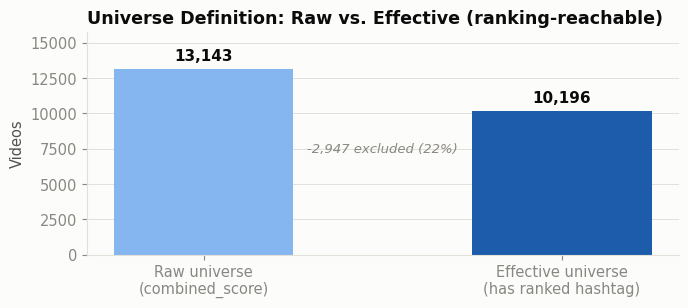

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
stages = ["Raw universe\n(combined_score)", "Effective universe\n(has ranked hashtag)"]
values = [video.video_id.nunique(), video_eff.video_id.nunique()]
colors = [BLUE_RAMP[250], BLUE_RAMP[550]]
bars = ax.bar(stages, values, color=colors, width=0.5)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=INK_PRIMARY, xytext=(0, 4), textcoords="offset points")
ax.annotate(f"-{excluded_n:,} excluded ({excluded_n / video.video_id.nunique():.0%})",
            (0.5, max(values) * 0.55), ha="center", fontsize=9.5, color=INK_MUTED, style="italic")
ax.set_ylim(0, max(values) * 1.2)
ax.set_ylabel("Videos")
ax.set_title("Universe Definition: Raw vs. Effective (ranking-reachable)", loc="left", fontweight="bold")
ax.grid(axis="y", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [5]:
pct_kept = video_eff.video_id.nunique() / video.video_id.nunique()
insight(
    f"**{excluded_n:,} videos** ({1 - pct_kept:.1%} of the raw universe) are unreachable by *any* method here - "
    f"including Random - because none of their hashtags appear on the {PINNED_DATE} ranking snapshot. "
    f"The **{video_eff.video_id.nunique():,}-video effective universe** ({pct_kept:.1%}) is what all budget, "
    "quota, and metric calculations in the rest of this notebook are measured against."
)

**Insight.** **2,947 videos** (22.4% of the raw universe) are unreachable by *any* method here - including Random - because none of their hashtags appear on the 2026-06-27 ranking snapshot. The **10,196-video effective universe** (77.6%) is what all budget, quota, and metric calculations in the rest of this notebook are measured against.

## 4. Video &rarr; Cell Assignment (Country x BPC Type)

Every video in the effective universe is assigned to exactly one of **8
cells** (`{ID, MY, PH, TH} x {BEAUTY, NON BEAUTY}`) via the two-step rule
from Section 3.2 of the proposal:

1. **Type:** `BEAUTY` if *any* hashtag edge is `HASHTAG_TYPE = BEAUTY` (inclusive-OR).
2. **Country:** among edges matching the assigned type, the one with the
   **lowest `RANKING`** (comparable across categories, unlike `RANK_POSITION_NUMBER`).

This keeps the 8 cells disjoint by construction - no video is ever sampled
from more than one cell.

In [6]:
vid_type = edges.groupby("VIDEO_ID")["HASHTAG_TYPE"].apply(lambda s: "BEAUTY" if (s == "BEAUTY").any() else "NON BEAUTY")
edges = edges.merge(vid_type.rename("assigned_type"), on="VIDEO_ID")

same_type_edges = edges[edges["HASHTAG_TYPE"] == edges["assigned_type"]]
best_edge = same_type_edges.loc[same_type_edges.groupby("VIDEO_ID")["RANKING"].idxmin()]
vid_country = best_edge.set_index("VIDEO_ID")["COUNTRY_CODE"].rename("assigned_country")
edges = edges.merge(vid_country, on="VIDEO_ID")

# One row per video: its final (country, type) cell - used to restrict per-cell sub-universes.
vid_cell = edges.drop_duplicates("VIDEO_ID").set_index("VIDEO_ID")[["assigned_country", "assigned_type"]]
video_cell = video_eff.merge(vid_cell, left_on="video_id", right_index=True)

# Each video's primary category (from the same edge that drove its cell assignment) - used so
# Category Balance counts one vote per video, consistent with how Creator Diversity counts videos.
vid_primary_category = best_edge.set_index("VIDEO_ID")["CATEGORY_NAME"].rename("primary_category")
video_cell = video_cell.merge(vid_primary_category, left_on="video_id", right_index=True)

cell_sizes = video_cell.groupby(["assigned_country", "assigned_type"]).size().unstack().reindex(COUNTRIES)[TYPES]
cell_sizes.columns = ["Beauty", "Non-Beauty"]
cell_sizes.loc["Total"] = cell_sizes.sum()
cell_sizes

,Beauty,Non-Beauty
assigned_country,,
ID,1379,1716
MY,1368,1091
PH,1409,1426
TH,933,874
Total,5089,5107


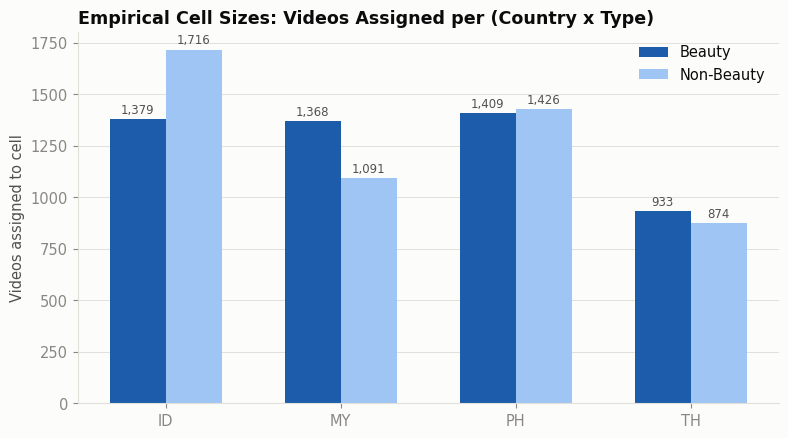

In [7]:
plot_df = cell_sizes.drop("Total")
x = np.arange(len(plot_df))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - width / 2, plot_df["Beauty"], width, label="Beauty", color=BLUE_RAMP[550])
b2 = ax.bar(x + width / 2, plot_df["Non-Beauty"], width, label="Non-Beauty", color=BLUE_RAMP[200])
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():,.0f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8.5, color=INK_SECONDARY, xytext=(0, 2), textcoords="offset points")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylabel("Videos assigned to cell")
ax.set_title("Empirical Cell Sizes: Videos Assigned per (Country x Type)", loc="left", fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [8]:
stacked = plot_df.stack()
big_cell, small_cell = stacked.idxmax(), stacked.idxmin()
id_gap = plot_df.loc["ID", "Non-Beauty"] - plot_df.loc["ID", "Beauty"]
insight(
    f"Largest cell: **{big_cell[0]}-{big_cell[1]}** ({stacked.max():,} videos). Smallest: **{small_cell[0]}-{small_cell[1]}** "
    f"({stacked.min():,}) - Thailand has the smallest pool in both segments, worth watching if the total budget is "
    "ever scaled up (see the feasibility ceiling below). Indonesia is the only country where Non-Beauty clearly "
    f"outnumbers Beauty ({plot_df.loc['ID', 'Non-Beauty']:,} vs {plot_df.loc['ID', 'Beauty']:,}, a gap of {id_gap:,}); "
    "elsewhere the two segments are closer in size."
)

**Insight.** Largest cell: **ID-Non-Beauty** (1,716 videos). Smallest: **TH-Non-Beauty** (874) - Thailand has the smallest pool in both segments, worth watching if the total budget is ever scaled up (see the feasibility ceiling below). Indonesia is the only country where Non-Beauty clearly outnumbers Beauty (1,716 vs 1,379, a gap of 337); elsewhere the two segments are closer in size.

## 5. Budget & Quota Design

Fixed business rule (Section 4.1 of the proposal): **50% Indonesia**
(remainder split evenly TH/MY/PH), **80% Beauty / 20% Non-Beauty**, crossed
as an independent 2D allocation across the 8 cells. `largest_remainder`
guarantees the 8 targets sum to exactly `BUDGET`, avoiding rounding drift.

In [9]:
def largest_remainder(weights: pd.Series, total: int) -> pd.Series:
    if weights.sum() == 0:
        return pd.Series(0, index=weights.index)
    raw = weights / weights.sum() * total
    base = np.floor(raw)
    remainder = int(total - base.sum())
    order = (raw - base).sort_values(ascending=False).index
    base.loc[order[:remainder]] += 1
    return base.astype(int)


def top_up(selected: set, budget: int, ranked_pool: list) -> set:
    if len(selected) >= budget:
        return selected
    out = set(selected)
    for vid in ranked_pool:
        if len(out) >= budget:
            break
        out.add(vid)
    return out


cell_share = pd.Series({(c, t): COUNTRY_SHARE[c] * TYPE_SHARE[t] for c in COUNTRIES for t in TYPES})
cell_budget = largest_remainder(cell_share, BUDGET)

budget_table = cell_budget.unstack()[TYPES]
budget_table.columns = ["Beauty", "Non-Beauty"]
budget_table = budget_table.reindex(COUNTRIES)
budget_table.loc["Total"] = budget_table.sum()
budget_table["Total"] = budget_table.sum(axis=1)
budget_table

,Beauty,Non-Beauty,Total
ID,800,200,1000
MY,267,67,334
PH,267,66,333
TH,267,66,333
Total,1601,399,2000


In [10]:
id_share = budget_table.loc["ID", "Total"] / BUDGET
insight(
    f"**Indonesia alone receives {budget_table.loc['ID', 'Total']:,} videos** ({id_share:.0%} of the {BUDGET:,}-video "
    "budget) - as much as Malaysia, the Philippines, and Thailand combined. Within every single country, Beauty "
    "gets **4x** the budget of Non-Beauty (80/20 split) - a fixed business rule, not a reflection of the underlying "
    "hashtag population, where Beauty is only ~6% of all hashtags."
)

**Insight.** **Indonesia alone receives 1,000 videos** (50% of the 2,000-video budget) - as much as Malaysia, the Philippines, and Thailand combined. Within every single country, Beauty gets **4x** the budget of Non-Beauty (80/20 split) - a fixed business rule, not a reflection of the underlying hashtag population, where Beauty is only ~6% of all hashtags.

In [11]:
# Feasibility ceiling: smallest (available population / cell budget share) across cells bounds
# how far total BUDGET could scale before this quota becomes infeasible.
available = video_cell.groupby(["assigned_country", "assigned_type"]).size()
available.index = available.index.set_names(["country", "type"])
share_flat = cell_share.copy()
share_flat.index = share_flat.index.set_names(["country", "type"])
ceiling = (available / share_flat).sort_values()
binding_cell, binding_ceiling = ceiling.index[0], ceiling.iloc[0]

print("Feasibility ceiling per cell (available population / cell's share of total budget):")
print(ceiling.round(0))
print()
print(f"Binding constraint: {binding_cell} -> max total budget before quota breaks ~= {binding_ceiling:,.0f}")
print(f"Current BUDGET = {BUDGET:,} is {BUDGET / binding_ceiling:.1%} of that ceiling - comfortable headroom.")

Feasibility ceiling per cell (available population / cell's share of total budget):
country  type      
ID       BEAUTY         3448.0
TH       BEAUTY         6998.0
MY       BEAUTY        10260.0
PH       BEAUTY        10568.0
ID       NON BEAUTY    17160.0
TH       NON BEAUTY    26220.0
MY       NON BEAUTY    32730.0
PH       NON BEAUTY    42780.0
dtype: float64

Binding constraint: ('ID', 'BEAUTY') -> max total budget before quota breaks ~= 3,448
Current BUDGET = 2,000 is 58.0% of that ceiling - comfortable headroom.


## 6. Score Correlation Check

Methods 3-5 rank videos within a hashtag using `virality_score`,
`trending_score`, or their average. Before running all three, we verify the
two underlying signals aren't near-duplicates of each other.

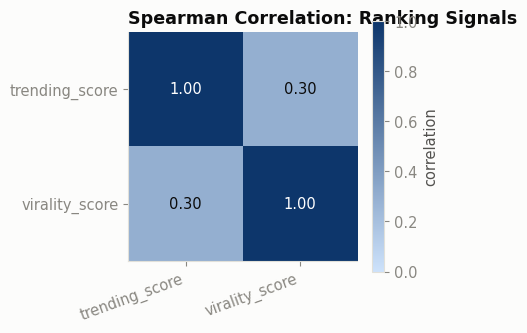

In [12]:
corr = video[["trending_score", "virality_score"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr.values, cmap=BLUE_CMAP, vmin=0, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=20, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        txt_color = "white" if val > 0.6 else INK_PRIMARY
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=10.5)
ax.set_title("Spearman Correlation: Ranking Signals", loc="left", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
fig.tight_layout()
plt.show()

In [13]:
rho = corr.loc["trending_score", "virality_score"]
insight(
    f"`trending_score` and `virality_score` correlate only **moderately** (rho={rho:.2f}) - not near 1.0 - so "
    "Methods 3 and 4 are expected to select meaningfully different videos, and Method 5's average of the two is a "
    "genuine blend rather than redundant with either input."
)

**Insight.** `trending_score` and `virality_score` correlate only **moderately** (rho=0.30) - not near 1.0 - so Methods 3 and 4 are expected to select meaningfully different videos, and Method 5's average of the two is a genuine blend rather than redundant with either input.

## 7. Per-Cell Sub-Universes

Each cell's sampling operates on edges where **both** the hashtag's own
`(COUNTRY_CODE, HASHTAG_TYPE)` and the video's assigned cell match - a
hashtag's raw linkage count is not the same as its effective in-cell pool,
since some linked videos may have been assigned to a different cell.

In [14]:
cell_edges = {}
cell_videos = {}
for c in COUNTRIES:
    for t in TYPES:
        mask = (
            (edges["COUNTRY_CODE"] == c) & (edges["HASHTAG_TYPE"] == t) &
            (edges["assigned_country"] == c) & (edges["assigned_type"] == t)
        )
        cell_edges[(c, t)] = edges[mask].copy()
        cell_videos[(c, t)] = video_cell[(video_cell["assigned_country"] == c) & (video_cell["assigned_type"] == t)].copy()

print(f"{'cell':<14}{'hashtags':>10}{'videos':>10}{'edges':>10}")
for c in COUNTRIES:
    for t in TYPES:
        ce, cv = cell_edges[(c, t)], cell_videos[(c, t)]
        print(f"{c + '-' + t:<14}{ce.HASHTAG_ID.nunique():>10,}{cv.shape[0]:>10,}{ce.shape[0]:>10,}")

cell            hashtags    videos     edges
ID-BEAUTY            142     1,379     1,531
ID-NON BEAUTY        247     1,716     2,133
MY-BEAUTY            153     1,368     1,560
MY-NON BEAUTY        169     1,091     1,293
PH-BEAUTY            175     1,409     1,627
PH-NON BEAUTY        224     1,426     1,664
TH-BEAUTY             69       933     1,008
TH-NON BEAUTY        139       874       957


## 8. Six Sampling Methods

All methods share the mechanics from Section 5.1-5.3 of the proposal, run
independently per cell. (The original design also had an **M6 - Top-K by
`view_count`** variant; it was dropped after review, so the method numbering
below has a gap at M6 by design, not by accident.)

- **M1 - Broad (Rank Position):** top-K hashtags **per category** in the
  cell (`RANK_POSITION_NUMBER`), extract all their videos. K found
  iteratively; `top_up` fills any shortfall.
- **M2 - Narrow (Ranking):** top-N hashtags **across the whole cell**
  (`RANKING`), extract all their videos.
- **M3-M5 - Top-K per hashtag:** every hashtag in the cell contributes its
  top-K videos, ranked by `virality_score` / `trending_score` / their
  average respectively.
- **M7 - Random baseline:** uniform draw without replacement, still inside
  the cell (i.e. inside the quota).

In [15]:
def method_broad_rank_position(cedges: pd.DataFrame, budget: int):
    '''M1: top-K hashtags per category (RANK_POSITION_NUMBER), extract all videos.'''
    if cedges.empty or budget <= 0:
        return set(), 0, set()
    cat_groups = {
        cat: g.drop_duplicates("HASHTAG_ID").sort_values("RANK_POSITION_NUMBER")["HASHTAG_ID"].tolist()
        for cat, g in cedges.groupby("CATEGORY_NAME")
    }
    hashtag_videos = {h: g["VIDEO_ID"].unique().tolist() for h, g in cedges.groupby("HASHTAG_ID")}
    max_len = max(len(v) for v in cat_groups.values())

    K, selected = 0, set()
    while K < max_len:
        K += 1
        candidate = set()
        for hashtags in cat_groups.values():
            for h in hashtags[:K]:
                candidate.update(hashtag_videos[h])
        if len(candidate) > budget:
            K -= 1
            break
        selected = candidate

    next_hashtags = [hashtags[K] for hashtags in cat_groups.values() if len(hashtags) > K]
    next_videos = list(dict.fromkeys(v for h in next_hashtags for v in hashtag_videos[h]))
    before_topup = set(selected)
    selected = top_up(selected, budget, next_videos)
    topup_ids = selected - before_topup
    touched_hashtags = len({h for hashtags in cat_groups.values() for h in hashtags[:K]})
    return selected, touched_hashtags, topup_ids


def method_narrow_ranking(cedges: pd.DataFrame, budget: int):
    '''M2: top-N hashtags across the whole cell (RANKING), extract all videos.'''
    if cedges.empty or budget <= 0:
        return set(), 0
    h_sorted = cedges.drop_duplicates("HASHTAG_ID").sort_values("RANKING")["HASHTAG_ID"].tolist()
    hashtag_videos = {h: g["VIDEO_ID"].unique().tolist() for h, g in cedges.groupby("HASHTAG_ID")}

    selected, touched = set(), 0
    for h in h_sorted:
        new_vids = [v for v in hashtag_videos[h] if v not in selected]
        if len(selected) + len(new_vids) <= budget:
            selected.update(new_vids)
            touched += 1
        else:
            selected.update(new_vids[: budget - len(selected)])
            touched += 1
            break
    return selected, touched


def method_topk_per_hashtag(cedges: pd.DataFrame, video_scores: pd.DataFrame, budget: int, score_col: str):
    '''M3-M5: every hashtag in the cell contributes its top-K videos by score_col.'''
    if cedges.empty or budget <= 0:
        return set(), set()
    merged = cedges.merge(video_scores[["video_id", score_col]], left_on="VIDEO_ID", right_on="video_id")
    groups = {h: g.sort_values(score_col, ascending=False)["VIDEO_ID"].tolist() for h, g in merged.groupby("HASHTAG_ID")}
    max_len = max(len(v) for v in groups.values())

    K, selected = 0, set()
    while K < max_len:
        K += 1
        candidate = set()
        for vids in groups.values():
            candidate.update(vids[:K])
        if len(candidate) > budget:
            K -= 1
            break
        selected = candidate

    next_pick = list(dict.fromkeys(vids[K] for vids in groups.values() if len(vids) > K))
    score_map = video_scores.set_index("video_id")[score_col]
    next_pick_sorted = sorted(next_pick, key=lambda v: -score_map.get(v, 0))
    before_topup = set(selected)
    selected = top_up(selected, budget, next_pick_sorted)
    topup_ids = selected - before_topup
    return selected, topup_ids


def method_random(cvideos: pd.DataFrame, budget: int, rng: np.random.Generator) -> set:
    '''M7: uniform draw without replacement, inside the cell.'''
    ids = cvideos["video_id"].values
    n = min(budget, len(ids))
    if n == 0:
        return set()
    return set(rng.choice(ids, size=n, replace=False).tolist())

## 9. Run All 6 Methods Across All 8 Cells

Because cells are disjoint by construction, each method's final selection is
simply the union of its 8 per-cell selections. `fill_log` records, per
method per cell, how close the method got to its target - important because
M1/M2 (extract-all) can under-fill a small cell while M3-M7 almost always
hit their target exactly.

In [16]:
rng = np.random.default_rng(RNG_SEED)

video_scores = video_cell[["video_id", "trending_score", "virality_score"]].copy()
video_scores["avg_score"] = (video_scores["trending_score"] + video_scores["virality_score"]) / 2

selections_by_cell = {m: {} for m in METHOD_KEYS}
topup_by_cell = {m: {} for m in METHOD_KEYS}
fill_log = []

for c in COUNTRIES:
    for t in TYPES:
        cell = (c, t)
        ce, cv = cell_edges[cell], cell_videos[cell]
        b = int(cell_budget[cell])
        vs = video_scores[video_scores["video_id"].isin(cv["video_id"])]

        sel1, touched1, topup1 = method_broad_rank_position(ce, b)
        sel2, touched2 = method_narrow_ranking(ce, b)
        sel3, topup3 = method_topk_per_hashtag(ce, vs, b, "virality_score")
        sel4, topup4 = method_topk_per_hashtag(ce, vs, b, "trending_score")
        sel5, topup5 = method_topk_per_hashtag(ce, vs, b, "avg_score")
        sel7 = method_random(cv, b, rng)

        sels = {"M1": sel1, "M2": sel2, "M3": sel3, "M4": sel4, "M5": sel5, "M7": sel7}
        touched = {"M1": touched1, "M2": touched2}
        topups = {"M1": topup1, "M2": set(), "M3": topup3, "M4": topup4, "M5": topup5, "M7": set()}
        for m, sel in sels.items():
            selections_by_cell[m][cell] = sel
            topup_by_cell[m][cell] = topups[m]
            fill_log.append({
                "method": m, "country": c, "type": t, "target": b, "selected": len(sel),
                "fill_rate": len(sel) / b if b else np.nan, "hashtags_touched": touched.get(m, np.nan),
            })

fill_log = pd.DataFrame(fill_log)
selections = {m: set().union(*selections_by_cell[m].values()) for m in METHOD_KEYS}

summary = pd.DataFrame({
    "method": [KEY_TO_LABEL[m] for m in METHOD_KEYS],
    "total_selected": [len(selections[m]) for m in METHOD_KEYS],
    "overall_fill_rate": [len(selections[m]) / BUDGET for m in METHOD_KEYS],
    "worst_cell_fill_rate": [fill_log[fill_log.method == m]["fill_rate"].min() for m in METHOD_KEYS],
    "est_cost_rupiah": [len(selections[m]) * COST_PER_VIDEO for m in METHOD_KEYS],
}).set_index("method")
summary

,total_selected,overall_fill_rate,worst_cell_fill_rate,est_cost_rupiah
method,,,,
M1 Broad (Rank Position),2000,1.0,1.0,400000
M2 Narrow (Ranking),2000,1.0,1.0,400000
M3 Top-K (Virality),2000,1.0,1.0,400000
M4 Top-K (Trending),2000,1.0,1.0,400000
M5 Top-K (Avg Score),2000,1.0,1.0,400000
M7 Random Baseline,2000,1.0,1.0,400000


In [17]:
worst_fill_overall = summary["worst_cell_fill_rate"].min()
insight(
    f"Every method reaches exactly **{BUDGET:,} selected videos** (Rp{BUDGET * COST_PER_VIDEO:,.0f} at "
    f"Rp{COST_PER_VIDEO}/video) - so the comparison below is on equal cost. Worst-case single-cell fill rate across "
    f"all methods is **{worst_fill_overall:.0%}**, meaning no method/cell combination ran out of eligible hashtags "
    "before reaching its quota target at this budget level."
)

**Insight.** Every method reaches exactly **2,000 selected videos** (Rp400,000 at Rp200/video) - so the comparison below is on equal cost. Worst-case single-cell fill rate across all methods is **100%**, meaning no method/cell combination ran out of eligible hashtags before reaching its quota target at this budget level.

## 10. Coverage Metrics (Per Cell)

The 7 core metrics from Section 6.1 of the proposal, computed per cell:

1. **Coverage Ratio** - mean, over the cell's hashtags, of (selected views / hashtag `VIEW_COUNT`).
2. **Breadth Coverage** - distinct hashtags touched / total hashtags in the cell.
3. **Category Balance** - entropy of selected videos' `primary_category` (one vote per video), normalized by `log(4)` (Beauty) or `log(57)` (Non-Beauty).
4. **Creator Diversity** - entropy of selected `uploader`s, normalized by `log(unique uploaders in cell)`.
5. **Trending / Virality Ratio** (reported separately, not averaged) - mean sample score / mean cell score.
6. **Long-tail Coverage** - % of selected videos whose best in-cell hashtag sits outside the top 50th percentile of its own category.
7. **Fill Rate** - already computed in Section 9.

In [18]:
def shannon_entropy(counts: pd.Series) -> float:
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def compute_cell_metrics(ce: pd.DataFrame, cv: pd.DataFrame, selected: set, cell_type: str) -> dict:
    sel_edges = ce[ce["VIDEO_ID"].isin(selected)]
    sel_video = cv[cv["video_id"].isin(selected)]

    # 1. Coverage ratio
    hashtag_view = ce.drop_duplicates("HASHTAG_ID").set_index("HASHTAG_ID")["hashtag_view_count"]
    valid_hashtags = hashtag_view[hashtag_view > 0]
    sel_edges_view = sel_edges.merge(cv[["video_id", "view_count"]], left_on="VIDEO_ID", right_on="video_id")
    touched_sum = sel_edges_view.groupby("HASHTAG_ID")["view_count"].sum()
    coverage_ratio = (touched_sum.reindex(valid_hashtags.index).fillna(0) / valid_hashtags).mean()

    # 2. Breadth coverage
    breadth = sel_edges["HASHTAG_ID"].nunique() / ce["HASHTAG_ID"].nunique() if ce["HASHTAG_ID"].nunique() else np.nan

    # 3. Category balance (video-level: each selected video counts once, via its primary_category -
    # consistent with how Creator Diversity counts videos, not hashtag edges)
    n_cat = N_CAT_BY_TYPE.get(cell_type, np.nan)
    category_balance = shannon_entropy(sel_video["primary_category"].value_counts()) / np.log(n_cat) if n_cat and n_cat > 1 else np.nan

    # 4. Creator diversity
    n_uploaders = cv["uploader"].nunique()
    creator_diversity = shannon_entropy(sel_video["uploader"].value_counts()) / np.log(n_uploaders) if n_uploaders > 1 else np.nan

    # 5. Trending / virality ratio (separate)
    trending_ratio = sel_video["trending_score"].mean() / cv["trending_score"].mean()
    virality_ratio = sel_video["virality_score"].mean() / cv["virality_score"].mean()

    # 6. Long-tail coverage
    best_pct = sel_edges.groupby("VIDEO_ID")["rank_percentile"].min()
    long_tail = float((best_pct > LONG_TAIL_PERCENTILE).mean()) if len(best_pct) else np.nan

    return {
        "coverage_ratio": coverage_ratio, "breadth_coverage": breadth, "category_balance": category_balance,
        "creator_diversity": creator_diversity, "trending_ratio": trending_ratio, "virality_ratio": virality_ratio,
        "long_tail_coverage": long_tail,
    }


CORE_METRICS = ["coverage_ratio", "breadth_coverage", "category_balance", "creator_diversity",
                "trending_ratio", "virality_ratio", "long_tail_coverage"]

metric_rows = []
for c in COUNTRIES:
    for t in TYPES:
        cell = (c, t)
        ce, cv = cell_edges[cell], cell_videos[cell]
        for m in METHOD_KEYS:
            row = {"method": m, "country": c, "type": t}
            row.update(compute_cell_metrics(ce, cv, selections_by_cell[m][cell], t))
            metric_rows.append(row)

metrics_long = pd.DataFrame(metric_rows)
metrics_long.head(8)

,method,country,type,coverage_ratio,breadth_coverage,category_balance,creator_diversity,trending_ratio,virality_ratio,long_tail_coverage
0,M1,ID,BEAUTY,1.741402,0.788732,0.913331,0.913123,1.037158,0.992918,0.09250
1,M2,ID,BEAUTY,1.148321,0.725352,0.718656,0.911673,1.073595,1.003224,0.04375
2,M3,ID,BEAUTY,2.156566,1.000000,0.864340,0.925408,0.997482,1.140765,0.24625
3,M4,ID,BEAUTY,2.303323,1.000000,0.856478,0.921353,1.027583,1.046725,0.24875
4,M5,ID,BEAUTY,2.207291,1.000000,0.861750,0.924433,1.013225,1.134740,0.24500
5,M7,ID,BEAUTY,1.431637,0.852113,0.834866,0.927162,0.997638,0.993731,0.22500
6,M1,ID,NON BEAUTY,0.118909,0.198381,0.607001,0.664036,1.058628,1.111811,0.00000
7,M2,ID,NON BEAUTY,0.333212,0.234818,0.422201,0.569776,1.147104,1.130264,0.00000


## 11. Macro-Averaged Scorecard

The main scorecard aggregates the 8 per-cell values with a **simple,
equal-weight average** - not a population-weighted one - so the (smaller)
Beauty cells carry the same analytical weight as the (larger) Non-Beauty
cells, consistent with the BPC-aware intent of this design.

In [19]:
scorecard = metrics_long.groupby("method")[CORE_METRICS].mean().loc[METHOD_KEYS]
scorecard.index = [KEY_TO_LABEL[m] for m in scorecard.index]
scorecard.style.format("{:.3f}").background_gradient(cmap=BLUE_CMAP, axis=0)

,coverage_ratio,breadth_coverage,category_balance,creator_diversity,trending_ratio,virality_ratio,long_tail_coverage
M1 Broad (Rank Position),6.542,0.321,0.620,0.716,1.067,1.054,0.012
M2 Narrow (Ranking),2.738,0.306,0.480,0.701,1.116,1.083,0.014
M3 Top-K (Virality),10.673,0.784,0.793,0.733,1.058,1.410,0.158
M4 Top-K (Trending),9.547,0.801,0.769,0.730,1.162,1.112,0.144
M5 Top-K (Avg Score),10.586,0.796,0.783,0.732,1.112,1.373,0.153
M7 Random Baseline,5.492,0.517,0.725,0.732,0.992,1.006,0.155


In [20]:
best_per_metric = scorecard.idxmax()
n_metrics_won = best_per_metric.value_counts()
leader = n_metrics_won.idxmax()
leader_metrics = ", ".join(f"`{m}`" for m in best_per_metric[best_per_metric == leader].index)
insight(
    f"No single method tops all 7 metrics - best-per-metric winners are spread across **{best_per_metric.nunique()}** "
    f"different methods. **{leader}** leads on the most ({n_metrics_won.max()} of 7): {leader_metrics}. "
    "The full method-by-method ranking for every metric is in Section 14."
)

**Insight.** No single method tops all 7 metrics - best-per-metric winners are spread across **2** different methods. **M3 Top-K (Virality)** leads on the most (5 of 7): `coverage_ratio`, `category_balance`, `creator_diversity`, `virality_ratio`, `long_tail_coverage`. The full method-by-method ranking for every metric is in Section 14.

### Sanity-check columns (reported, not ranked on)

`Country Balance` and realized Beauty share are fixed by the quota and
should look nearly identical across all 6 methods - they verify the quota
was implemented correctly, not which method is "better".

In [21]:
def country_balance(selected: set) -> float:
    countries = vid_cell.loc[list(selected), "assigned_country"] if selected else pd.Series(dtype=object)
    return shannon_entropy(countries.value_counts()) / np.log(len(COUNTRIES)) if len(countries) else np.nan


sanity = pd.DataFrame({
    "method": [KEY_TO_LABEL[m] for m in METHOD_KEYS],
    "country_balance": [country_balance(selections[m]) for m in METHOD_KEYS],
    "beauty_share_realized": [
        vid_cell.loc[list(selections[m]), "assigned_type"].eq("BEAUTY").mean() if selections[m] else np.nan
        for m in METHOD_KEYS
    ],
}).set_index("method")
sanity["beauty_share_target"] = TYPE_SHARE["BEAUTY"]
sanity.style.format("{:.3f}")

,country_balance,beauty_share_realized,beauty_share_target
method,,,
M1 Broad (Rank Position),0.896,0.800,0.800
M2 Narrow (Ranking),0.896,0.800,0.800
M3 Top-K (Virality),0.896,0.800,0.800
M4 Top-K (Trending),0.896,0.800,0.800
M5 Top-K (Avg Score),0.896,0.800,0.800
M7 Random Baseline,0.896,0.800,0.800


In [22]:
insight(
    f"Country Balance ({sanity['country_balance'].mean():.3f} average, std {sanity['country_balance'].std():.4f}) "
    f"and realized Beauty share (all at {sanity['beauty_share_realized'].mean():.1%} vs a "
    f"{TYPE_SHARE['BEAUTY']:.0%} target) are **essentially identical across all 6 methods** - confirming the 8-cell "
    "quota is enforced consistently regardless of which within-cell method is used. Any performance differences "
    "seen elsewhere in this notebook come from the sampling logic, not from unequal quota application."
)

**Insight.** Country Balance (0.896 average, std 0.0000) and realized Beauty share (all at 80.0% vs a 80% target) are **essentially identical across all 6 methods** - confirming the 8-cell quota is enforced consistently regardless of which within-cell method is used. Any performance differences seen elsewhere in this notebook come from the sampling logic, not from unequal quota application.

## 12. Radar Chart: Macro-Averaged Scorecard

Metrics are min-max normalized across methods purely for the visual radar
shape (raw values remain in the scorecard table above).

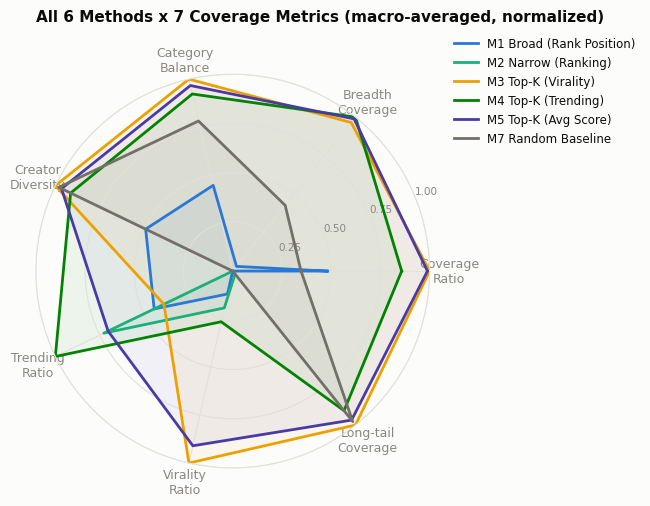

In [23]:
def radar_chart(ax, df: pd.DataFrame, labels: list, title: str, legend: bool = True):
    norm = df.apply(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0 + 0.5)
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    for method in df.index:
        values = norm.loc[method].tolist()
        values += values[:1]
        color = METHOD_COLOR[method]
        ax.plot(angles, values, linewidth=2, color=color, label=method)
        ax.fill(angles, values, color=color, alpha=0.06)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7.5, color=INK_MUTED)
    ax.set_ylim(0, 1)
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRIDLINE, linewidth=0.8)
    ax.spines["polar"].set_color(GRIDLINE)
    ax.set_title(title, loc="left", fontweight="bold", pad=18, fontsize=11)
    if legend:
        ax.legend(loc="upper right", bbox_to_anchor=(1.55, 1.12), frameon=False, fontsize=8.5)


fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
radar_chart(ax, scorecard, CORE_METRIC_LABELS, "All 6 Methods x 7 Coverage Metrics (macro-averaged, normalized)")
fig.tight_layout()
plt.show()

In [24]:
composite = scorecard.apply(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0 + 0.5).mean(axis=1).sort_values(ascending=False)
insight(
    f"Reading the radar shapes: **{composite.index[0]}** has the largest normalized footprint overall "
    f"(composite {composite.iloc[0]:.2f}), while **{composite.index[-1]}** has the smallest ({composite.iloc[-1]:.2f}). "
    "This composite is for orientation only, *not a recommendation* - see Section 14 for the exact per-metric "
    "ranking, and the proposal's caution against reading a single blended number as a winner."
)

**Insight.** Reading the radar shapes: **M5 Top-K (Avg Score)** has the largest normalized footprint overall (composite 0.93), while **M2 Narrow (Ranking)** has the smallest (0.13). This composite is for orientation only, *not a recommendation* - see Section 14 for the exact per-metric ranking, and the proposal's caution against reading a single blended number as a winner.

## 13. Faceted Radar: Beauty vs. Non-Beauty

The split stakeholders will ask about first - are the same methods strong
in both segments, or does the ranking flip once we isolate Beauty cells?

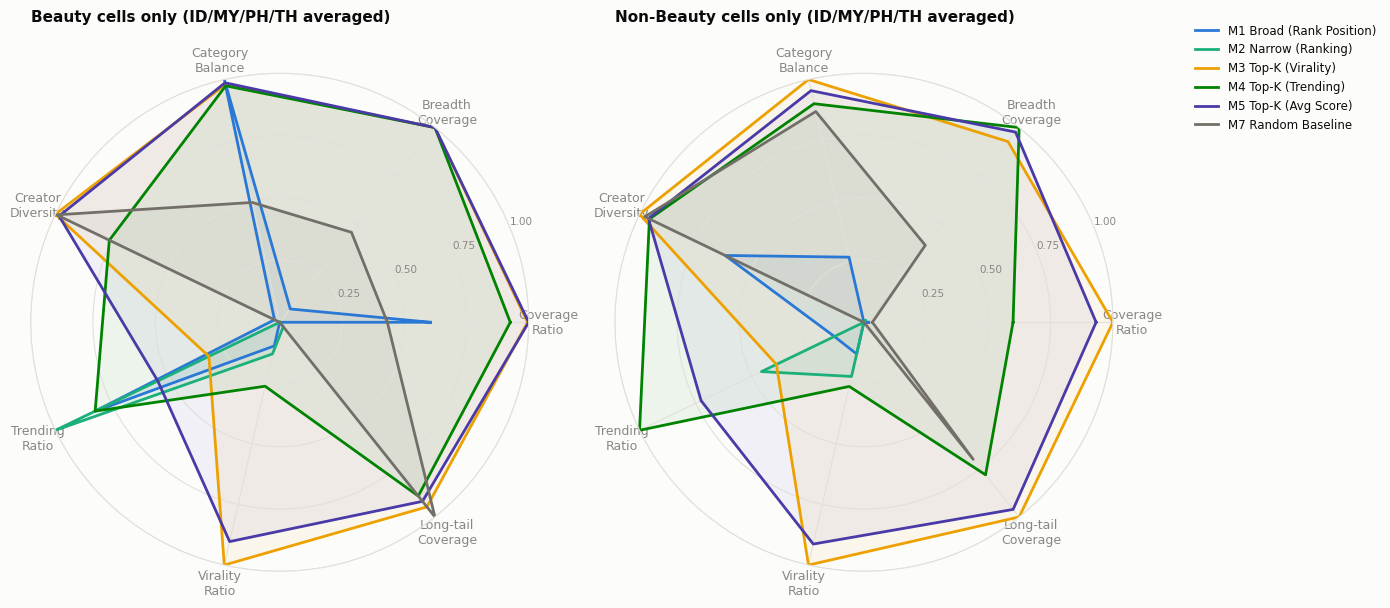

In [25]:
beauty_scorecard = metrics_long[metrics_long.type == "BEAUTY"].groupby("method")[CORE_METRICS].mean().loc[METHOD_KEYS]
nonbeauty_scorecard = metrics_long[metrics_long.type == "NON BEAUTY"].groupby("method")[CORE_METRICS].mean().loc[METHOD_KEYS]
beauty_scorecard.index = [KEY_TO_LABEL[m] for m in beauty_scorecard.index]
nonbeauty_scorecard.index = [KEY_TO_LABEL[m] for m in nonbeauty_scorecard.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True))
radar_chart(axes[0], beauty_scorecard, CORE_METRIC_LABELS, "Beauty cells only (ID/MY/PH/TH averaged)", legend=False)
radar_chart(axes[1], nonbeauty_scorecard, CORE_METRIC_LABELS, "Non-Beauty cells only (ID/MY/PH/TH averaged)", legend=True)
fig.tight_layout()
plt.show()

In [26]:
def composite_rank(df: pd.DataFrame) -> pd.Series:
    norm = df.apply(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0 + 0.5)
    return norm.mean(axis=1).sort_values(ascending=False)


beauty_rank = composite_rank(beauty_scorecard)
nonbeauty_rank = composite_rank(nonbeauty_scorecard)
flipped = beauty_rank.index[0] != nonbeauty_rank.index[0]
insight(
    f"Top method in **Beauty** cells: **{beauty_rank.index[0]}** (composite {beauty_rank.iloc[0]:.2f}). "
    f"Top method in **Non-Beauty** cells: **{nonbeauty_rank.index[0]}** (composite {nonbeauty_rank.iloc[0]:.2f}). "
    + (
        "These differ - the overall leader is not automatically the best choice within Beauty specifically, "
        "which matters most for BPC-focused reporting."
        if flipped else
        "The same method leads both segments, a reassuring sign of consistency across the BPC split."
    )
)

**Insight.** Top method in **Beauty** cells: **M5 Top-K (Avg Score)** (composite 0.91). Top method in **Non-Beauty** cells: **M5 Top-K (Avg Score)** (composite 0.92). The same method leads both segments, a reassuring sign of consistency across the BPC split.

## 14. Coverage Metrics in Detail: Per-Metric Ranking

A radar chart is good for shape, but overlapping lines make exact ranking
hard to read off directly. This section gives each of the 7 core metrics
its own bar chart - one chart per metric, methods sorted by rank - so any
ordering that was ambiguous on the radar is unambiguous here. All 8 cells
pooled first; Beauty (BPC) and Non-Beauty (non-BPC) are broken out
separately right after, since the leader can differ once the BPC split is
isolated (see Section 13).

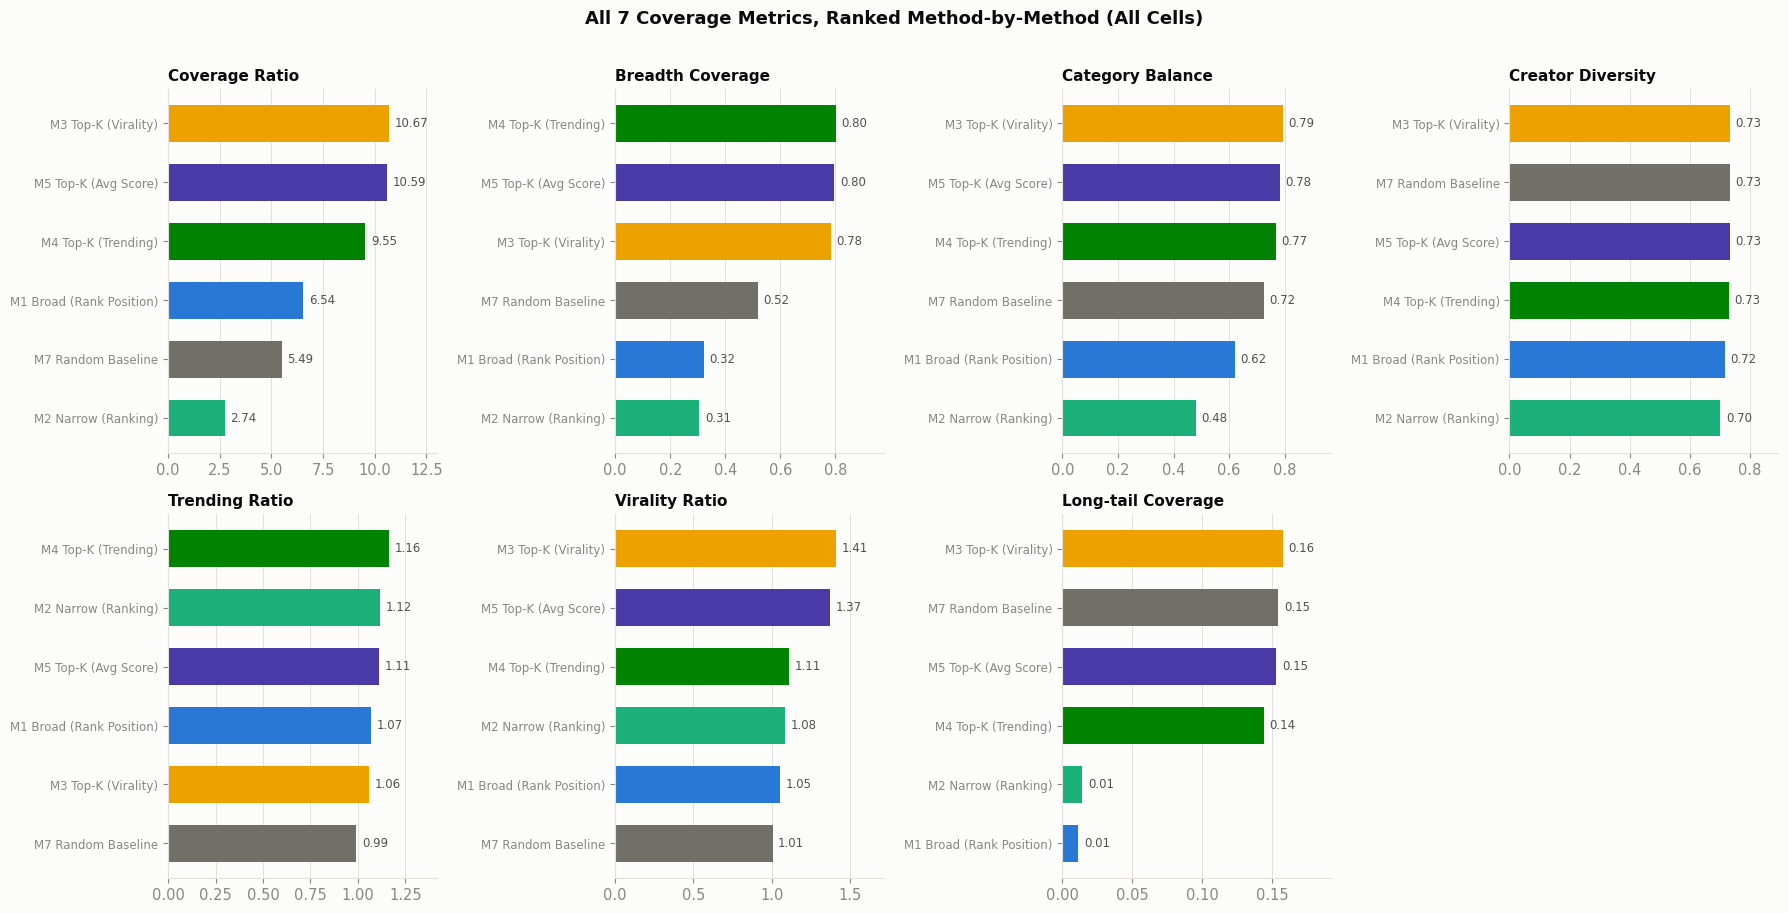

In [27]:
METRIC_TITLES = {
    "coverage_ratio": "Coverage Ratio", "breadth_coverage": "Breadth Coverage",
    "category_balance": "Category Balance", "creator_diversity": "Creator Diversity",
    "trending_ratio": "Trending Ratio", "virality_ratio": "Virality Ratio",
    "long_tail_coverage": "Long-tail Coverage",
}


def plot_metric_rankings(sc: pd.DataFrame, suptitle: str) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for ax, metric in zip(axes.flat, CORE_METRICS):
        ranked = sc[metric].sort_values(ascending=True)
        colors = [METHOD_COLOR[m] for m in ranked.index]
        bars = ax.barh(ranked.index, ranked.values, color=colors, height=0.62)
        for bar, v in zip(bars, ranked.values):
            ax.annotate(f"{v:.2f}", (bar.get_width(), bar.get_y() + bar.get_height() / 2), va="center", ha="left",
                        fontsize=8.5, color=INK_SECONDARY, xytext=(4, 0), textcoords="offset points")
        ax.set_xlim(0, ranked.values.max() * 1.22)
        ax.set_title(METRIC_TITLES[metric], loc="left", fontsize=11, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8.5)
        ax.grid(axis="x", linewidth=0.7)
        ax.set_axisbelow(True)

    for ax in axes.flat[len(CORE_METRICS):]:
        ax.axis("off")

    fig.suptitle(suptitle, fontweight="bold", y=1.01, fontsize=13)
    fig.tight_layout()
    plt.show()


plot_metric_rankings(scorecard, "All 7 Coverage Metrics, Ranked Method-by-Method (All Cells)")

In [28]:
lines = "\n".join(f"- **{METRIC_TITLES[m]}**: {scorecard[m].idxmax()} ({scorecard[m].max():.2f})" for m in CORE_METRICS)
insight(f"Top-ranked method per metric, all cells pooled:\n\n{lines}")

**Insight.** Top-ranked method per metric, all cells pooled:

- **Coverage Ratio**: M3 Top-K (Virality) (10.67)
- **Breadth Coverage**: M4 Top-K (Trending) (0.80)
- **Category Balance**: M3 Top-K (Virality) (0.79)
- **Creator Diversity**: M3 Top-K (Virality) (0.73)
- **Trending Ratio**: M4 Top-K (Trending) (1.16)
- **Virality Ratio**: M3 Top-K (Virality) (1.41)
- **Long-tail Coverage**: M3 Top-K (Virality) (0.16)

## 15. Per-Metric Ranking - Beauty (BPC) Cells Only

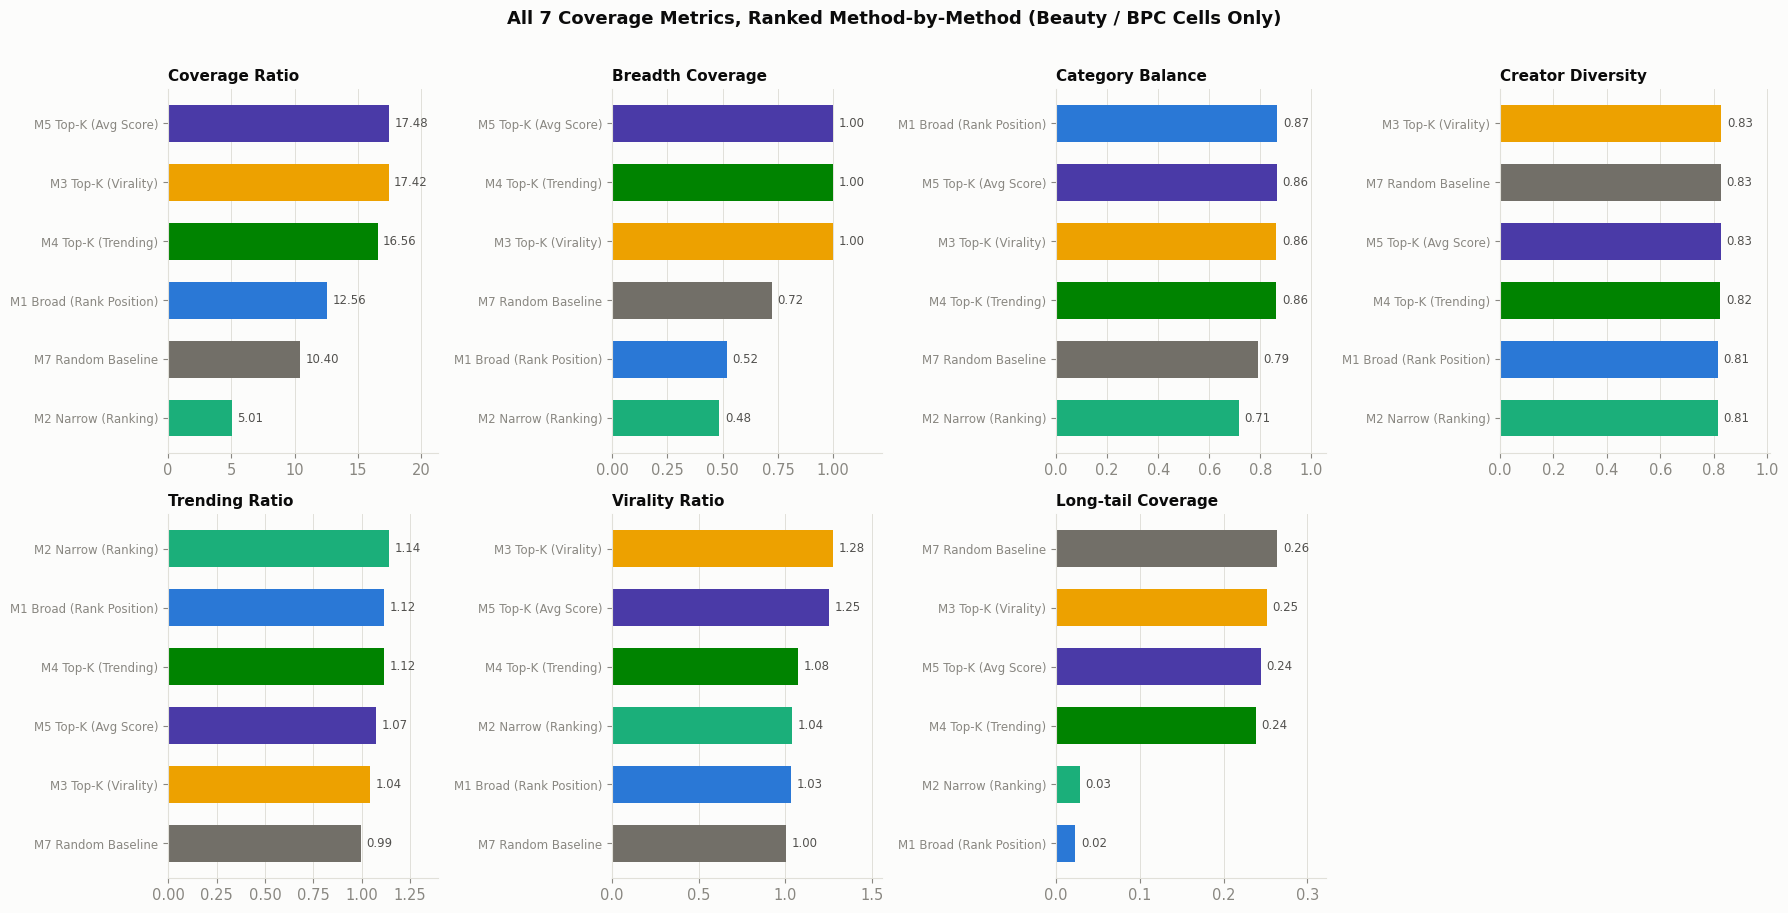

In [29]:
plot_metric_rankings(beauty_scorecard, "All 7 Coverage Metrics, Ranked Method-by-Method (Beauty / BPC Cells Only)")

In [30]:
lines = "\n".join(f"- **{METRIC_TITLES[m]}**: {beauty_scorecard[m].idxmax()} ({beauty_scorecard[m].max():.2f})" for m in CORE_METRICS)
insight(f"Top-ranked method per metric, **Beauty (BPC) cells only**:\n\n{lines}")

**Insight.** Top-ranked method per metric, **Beauty (BPC) cells only**:

- **Coverage Ratio**: M5 Top-K (Avg Score) (17.48)
- **Breadth Coverage**: M3 Top-K (Virality) (1.00)
- **Category Balance**: M1 Broad (Rank Position) (0.87)
- **Creator Diversity**: M3 Top-K (Virality) (0.83)
- **Trending Ratio**: M2 Narrow (Ranking) (1.14)
- **Virality Ratio**: M3 Top-K (Virality) (1.28)
- **Long-tail Coverage**: M7 Random Baseline (0.26)

## 16. Per-Metric Ranking - Non-Beauty (Non-BPC) Cells Only

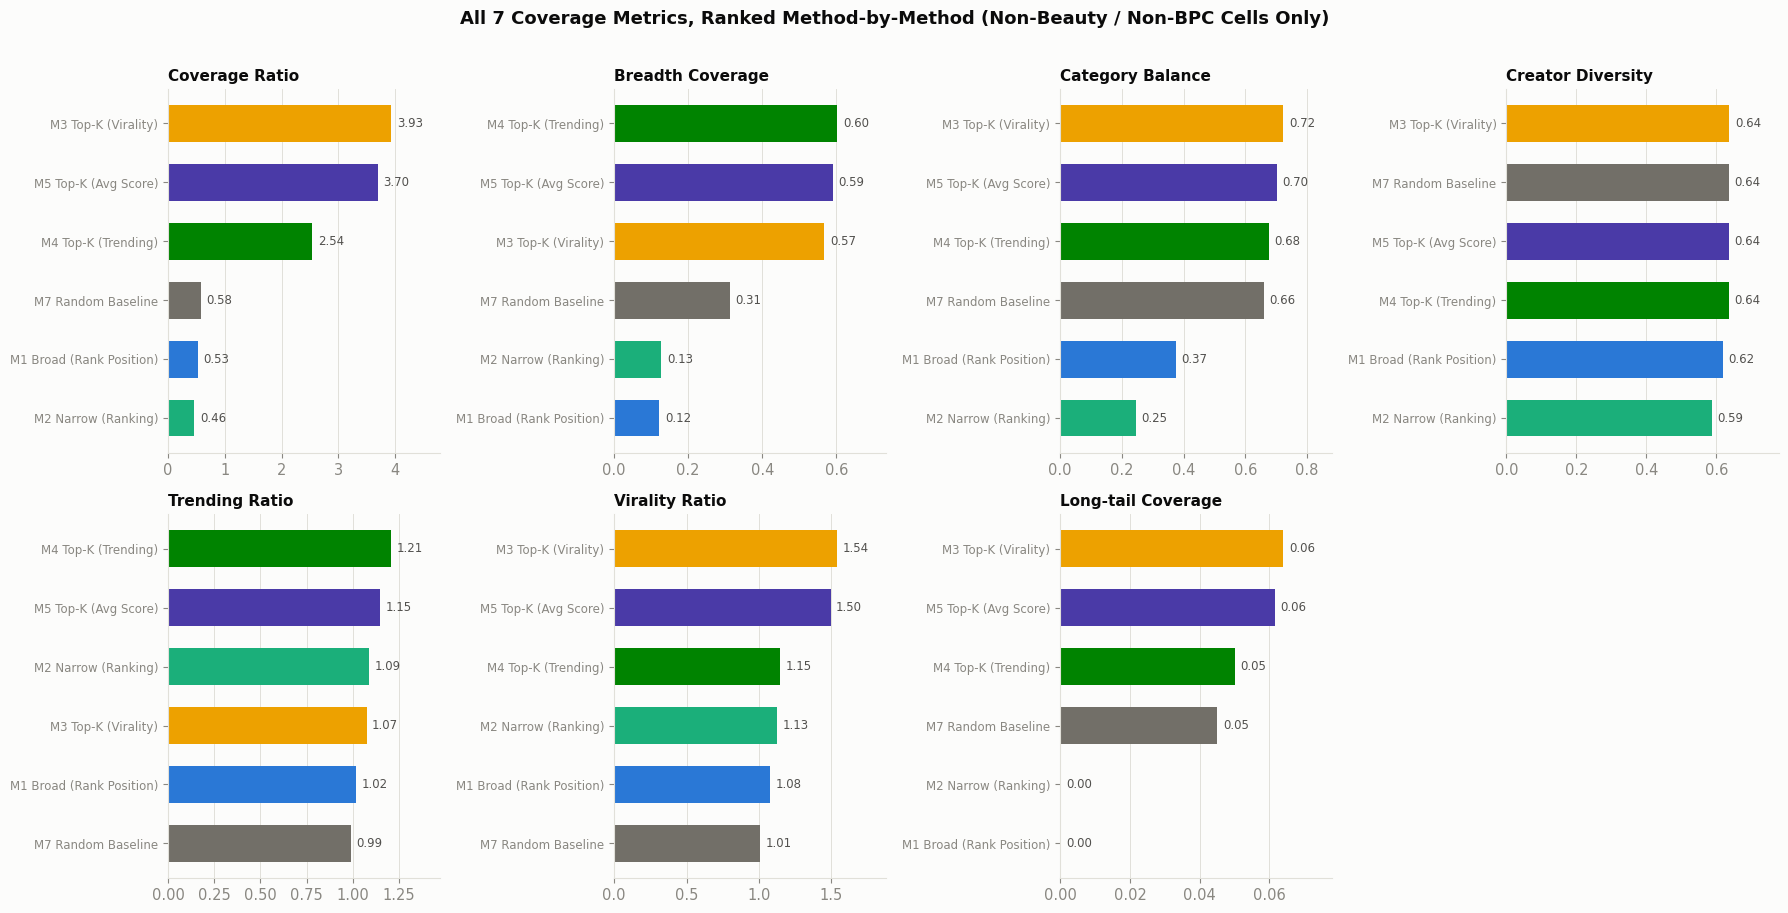

In [31]:
plot_metric_rankings(nonbeauty_scorecard, "All 7 Coverage Metrics, Ranked Method-by-Method (Non-Beauty / Non-BPC Cells Only)")

In [32]:
lines = "\n".join(f"- **{METRIC_TITLES[m]}**: {nonbeauty_scorecard[m].idxmax()} ({nonbeauty_scorecard[m].max():.2f})" for m in CORE_METRICS)
insight(f"Top-ranked method per metric, **Non-Beauty (non-BPC) cells only**:\n\n{lines}")

**Insight.** Top-ranked method per metric, **Non-Beauty (non-BPC) cells only**:

- **Coverage Ratio**: M3 Top-K (Virality) (3.93)
- **Breadth Coverage**: M4 Top-K (Trending) (0.60)
- **Category Balance**: M3 Top-K (Virality) (0.72)
- **Creator Diversity**: M3 Top-K (Virality) (0.64)
- **Trending Ratio**: M4 Top-K (Trending) (1.21)
- **Virality Ratio**: M3 Top-K (Virality) (1.54)
- **Long-tail Coverage**: M3 Top-K (Virality) (0.06)

In [33]:
flips = [METRIC_TITLES[m] for m in CORE_METRICS if beauty_scorecard[m].idxmax() != nonbeauty_scorecard[m].idxmax()]
if flips:
    text = (
        f"The top-ranked method **differs between Beauty and Non-Beauty** on **{len(flips)} of {len(CORE_METRICS)}** "
        f"metrics: {', '.join(flips)}. Any recommendation aimed specifically at BPC content should be checked "
        "against the Beauty-only ranking above, not the pooled one in Section 14."
    )
else:
    text = "The top-ranked method is the **same in both Beauty and Non-Beauty** cells for every single metric."
insight(text)

**Insight.** The top-ranked method **differs between Beauty and Non-Beauty** on **5 of 7** metrics: Coverage Ratio, Breadth Coverage, Category Balance, Trending Ratio, Long-tail Coverage. Any recommendation aimed specifically at BPC content should be checked against the Beauty-only ranking above, not the pooled one in Section 14.

## 17. Coverage Ratio by Method Family: Top-K-per-Hashtag vs. Extract-All

A pattern shows up consistently across Sections 14-16: the three **top-K
per hashtag** methods (M3-M5) beat the two **extract-all-hashtag-videos**
methods (M1-M2) on Coverage Ratio, by a wide margin. This chart makes that
grouping explicit - methods are colored **by family**, not individually, so
the two clusters are immediately visible rather than having to compare
separate colors one by one.

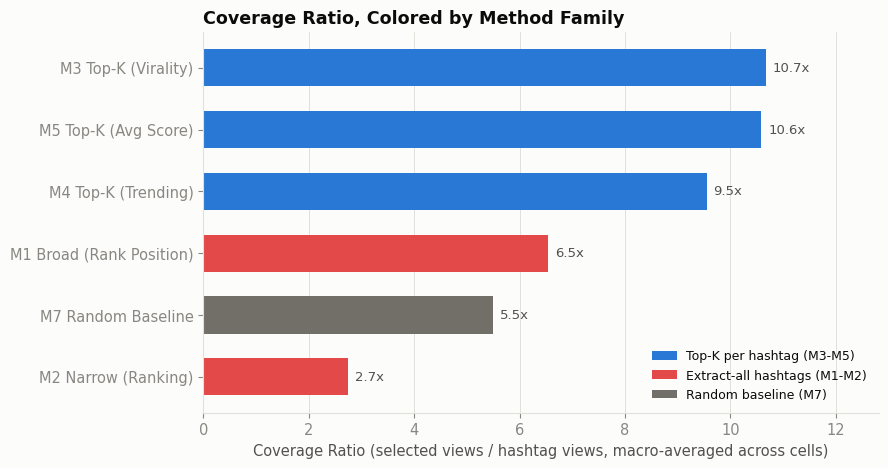

In [34]:
FAMILY_COLOR = {
    "M1 Broad (Rank Position)": CATEGORICAL["red"],
    "M2 Narrow (Ranking)": CATEGORICAL["red"],
    "M3 Top-K (Virality)": CATEGORICAL["blue"],
    "M4 Top-K (Trending)": CATEGORICAL["blue"],
    "M5 Top-K (Avg Score)": CATEGORICAL["blue"],
    "M7 Random Baseline": RANDOM_GRAY,
}

ranked = scorecard["coverage_ratio"].sort_values(ascending=True)
colors = [FAMILY_COLOR[m] for m in ranked.index]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(ranked.index, ranked.values, color=colors, height=0.6)
for bar, v in zip(bars, ranked.values):
    ax.annotate(f"{v:.1f}x", (bar.get_width(), bar.get_y() + bar.get_height() / 2), va="center", ha="left",
                fontsize=9.5, color=INK_SECONDARY, xytext=(5, 0), textcoords="offset points")
ax.set_xlabel("Coverage Ratio (selected views / hashtag views, macro-averaged across cells)")
ax.set_title("Coverage Ratio, Colored by Method Family", loc="left", fontweight="bold")
legend_handles = [
    Patch(facecolor=CATEGORICAL["blue"], label="Top-K per hashtag (M3-M5)"),
    Patch(facecolor=CATEGORICAL["red"], label="Extract-all hashtags (M1-M2)"),
    Patch(facecolor=RANDOM_GRAY, label="Random baseline (M7)"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, ranked.values.max() * 1.2)
ax.grid(axis="x", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [35]:
topk_methods = ["M3 Top-K (Virality)", "M4 Top-K (Trending)", "M5 Top-K (Avg Score)"]
extractall_methods = ["M1 Broad (Rank Position)", "M2 Narrow (Ranking)"]
topk_avg = scorecard.loc[topk_methods, "coverage_ratio"].mean()
extractall_avg = scorecard.loc[extractall_methods, "coverage_ratio"].mean()
insight(
    f"Top-K-per-hashtag methods (M3-M5) average **{topk_avg:.1f}x** coverage ratio vs **{extractall_avg:.1f}x** for "
    f"the extract-all methods (M1-M2) - roughly a **{topk_avg / extractall_avg:.1f}x** gap. This follows from how "
    "each family spends budget: extract-all methods take *every* video of a chosen hashtag, including many low-view "
    "ones, while top-K-per-hashtag methods always pick each hashtag's *best-scoring* videos first - so the same "
    "budget concentrates on higher-view content per hashtag touched."
)

**Insight.** Top-K-per-hashtag methods (M3-M5) average **10.3x** coverage ratio vs **4.6x** for the extract-all methods (M1-M2) - roughly a **2.2x** gap. This follows from how each family spends budget: extract-all methods take *every* video of a chosen hashtag, including many low-view ones, while top-K-per-hashtag methods always pick each hashtag's *best-scoring* videos first - so the same budget concentrates on higher-view content per hashtag touched.

## 18. Per-Cell Detail: Breadth Coverage & Coverage Ratio

Macro-averages can hide cell-specific behavior (e.g. a method collapsing in
one small cell while looking fine on average). These heatmaps show the raw
per-cell values behind two of the headline metrics.

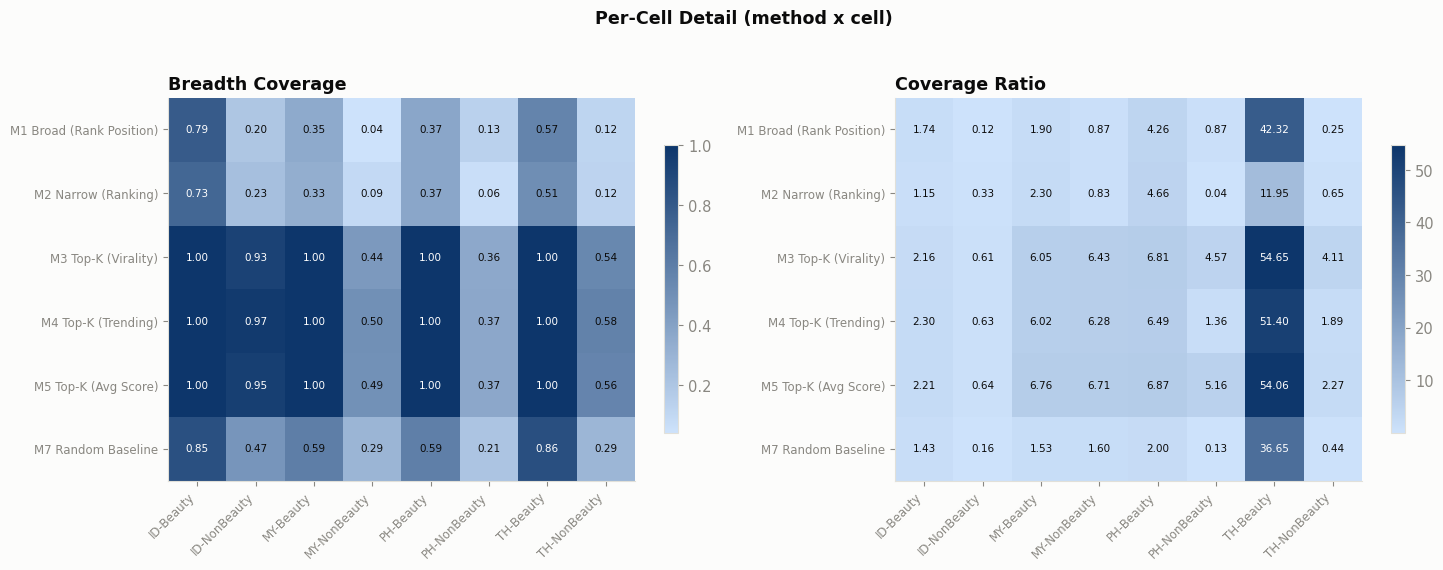

In [36]:
metrics_long["cell"] = metrics_long["country"] + "-" + metrics_long["type"].map({"BEAUTY": "Beauty", "NON BEAUTY": "NonBeauty"})
cell_order = [f"{c}-{t}" for c in COUNTRIES for t in ["Beauty", "NonBeauty"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, metric, title in zip(axes, ["breadth_coverage", "coverage_ratio"], ["Breadth Coverage", "Coverage Ratio"]):
    pivot = metrics_long.pivot(index="method", columns="cell", values=metric).loc[METHOD_KEYS, cell_order]
    im = ax.imshow(pivot.values, cmap=BLUE_CMAP, aspect="auto")
    ax.set_xticks(range(len(cell_order))); ax.set_xticklabels(cell_order, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(METHOD_KEYS))); ax.set_yticklabels([KEY_TO_LABEL[m] for m in METHOD_KEYS], fontsize=8.5)
    vmax = pivot.values.max()
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            color = "white" if val > vmax * 0.6 else INK_PRIMARY
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5, color=color)
    ax.set_title(title, loc="left", fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle("Per-Cell Detail (method x cell)", fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

In [37]:
breadth_pivot = metrics_long.pivot(index="method", columns="cell", values="breadth_coverage").loc[METHOD_KEYS, cell_order]
cov_pivot = metrics_long.pivot(index="method", columns="cell", values="coverage_ratio").loc[METHOD_KEYS, cell_order]
worst_breadth = breadth_pivot.stack().idxmin()
extreme_cov = cov_pivot.stack().idxmax()
insight(
    f"Lowest breadth anywhere: **{KEY_TO_LABEL[worst_breadth[0]]}** in `{worst_breadth[1]}` "
    f"({breadth_pivot.loc[worst_breadth]:.2f}) - expected for M1/M2 in smaller cells, since both deliberately "
    f"concentrate on few hashtags. Coverage ratio swings widely by cell, peaking at **{cov_pivot.loc[extreme_cov]:.1f}x** "
    f"in `{extreme_cov[1]}` for **{KEY_TO_LABEL[extreme_cov[0]]}** - a reminder (Section 27, limitation 6) that this "
    "metric's absolute scale isn't comparable across cells, only the relative ranking within a cell is."
)

**Insight.** Lowest breadth anywhere: **M1 Broad (Rank Position)** in `MY-NonBeauty` (0.04) - expected for M1/M2 in smaller cells, since both deliberately concentrate on few hashtags. Coverage ratio swings widely by cell, peaking at **54.6x** in `TH-Beauty` for **M3 Top-K (Virality)** - a reminder (Section 27, limitation 6) that this metric's absolute scale isn't comparable across cells, only the relative ranking within a cell is.

## 19. Fill Rate

M1/M2 extract *all* videos of selected hashtags, so a small cell can run out
of hashtags before reaching its target. This chart flags any method/cell
combination that under-filled.

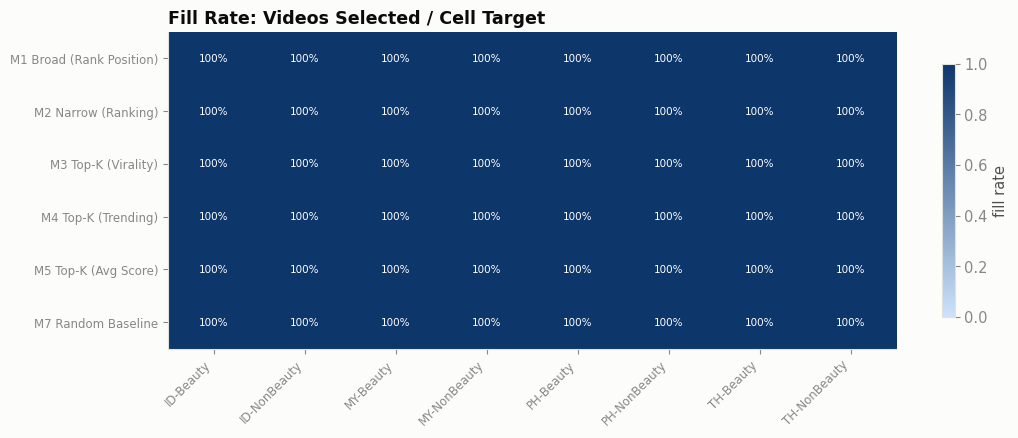

In [38]:
fill_pivot = fill_log.pivot_table(index="method", columns=["country", "type"], values="fill_rate").loc[METHOD_KEYS]
fill_pivot.columns = [f"{c}-{'Beauty' if t == 'BEAUTY' else 'NonBeauty'}" for c, t in fill_pivot.columns]
fill_pivot = fill_pivot[cell_order]

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(fill_pivot.values, cmap=BLUE_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cell_order))); ax.set_xticklabels(cell_order, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(METHOD_KEYS))); ax.set_yticklabels([KEY_TO_LABEL[m] for m in METHOD_KEYS], fontsize=8.5)
for i in range(fill_pivot.shape[0]):
    for j in range(fill_pivot.shape[1]):
        val = fill_pivot.values[i, j]
        color = "white" if val > 0.6 else INK_PRIMARY
        marker = f"{val:.0%}" if val < 0.999 else "100%"
        ax.text(j, i, marker, ha="center", va="center", fontsize=7.5, color=color, fontweight=("bold" if val < 0.95 else "normal"))
ax.set_title("Fill Rate: Videos Selected / Cell Target", loc="left", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="fill rate")
fig.tight_layout()
plt.show()

In [39]:
worst_fill_cell = fill_pivot.stack().min()
insight(
    f"Worst observed fill rate across all method x cell combinations is **{worst_fill_cell:.0%}** - "
    + (
        "every method reached its exact target in every cell at this budget level, so fill rate is not a "
        "differentiator here; it becomes relevant mainly if the total budget is pushed toward the feasibility "
        "ceiling calculated in Section 5."
        if worst_fill_cell >= 0.999 else
        "meaning at least one method/cell combination ran short of eligible hashtags to reach its target."
    )
)

**Insight.** Worst observed fill rate across all method x cell combinations is **100%** - every method reached its exact target in every cell at this budget level, so fill rate is not a differentiator here; it becomes relevant mainly if the total budget is pushed toward the feasibility ceiling calculated in Section 5.

## 20. Category Balance by Type

Beauty cells have a structural ceiling of 4 categories vs. 57 for
Non-Beauty; both are shown on their own 0-1 scale (already normalized by
their own type's category count), so the two bars below are comparable.

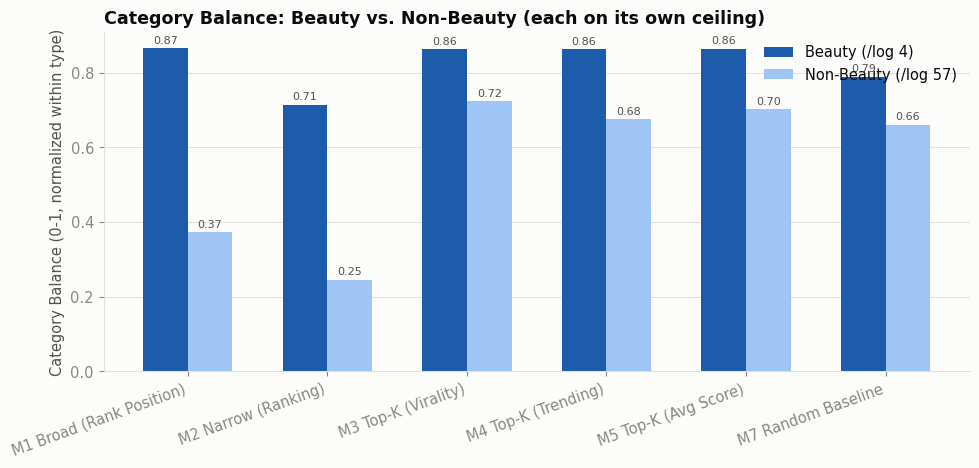

In [40]:
cat_balance = metrics_long.groupby(["method", "type"])["category_balance"].mean().unstack()[TYPES]
cat_balance = cat_balance.loc[METHOD_KEYS]
cat_balance.columns = ["Beauty", "Non-Beauty"]
cat_balance.index = [KEY_TO_LABEL[m] for m in METHOD_KEYS]

x = np.arange(len(cat_balance))
width = 0.32
fig, ax = plt.subplots(figsize=(10, 4.8))
b1 = ax.bar(x - width / 2, cat_balance["Beauty"], width, label="Beauty (/log 4)", color=BLUE_RAMP[550])
b2 = ax.bar(x + width / 2, cat_balance["Non-Beauty"], width, label="Non-Beauty (/log 57)", color=BLUE_RAMP[200])
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8, color=INK_SECONDARY, xytext=(0, 2), textcoords="offset points")
ax.set_xticks(x); ax.set_xticklabels(cat_balance.index, rotation=20, ha="right")
ax.set_ylabel("Category Balance (0-1, normalized within type)")
ax.set_title("Category Balance: Beauty vs. Non-Beauty (each on its own ceiling)", loc="left", fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [41]:
gap = cat_balance["Beauty"] - cat_balance["Non-Beauty"]
insight(
    f"Every method scores higher on Category Balance within **Beauty** than within **Non-Beauty** (average gap "
    f"**{gap.mean():+.2f}**), even though both are normalized to their own type's ceiling - Beauty's 4-category space "
    f"is structurally easier to spread evenly across than Non-Beauty's 57. **{cat_balance['Non-Beauty'].idxmin()}** "
    f"has the least balanced Non-Beauty spread ({cat_balance['Non-Beauty'].min():.2f})."
)

**Insight.** Every method scores higher on Category Balance within **Beauty** than within **Non-Beauty** (average gap **+0.26**), even though both are normalized to their own type's ceiling - Beauty's 4-category space is structurally easier to spread evenly across than Non-Beauty's 57. **M2 Narrow (Ranking)** has the least balanced Non-Beauty spread (0.25).

## 21. Trend-Stage Balance (Trending vs. Virality, Reported Separately)

A ratio of 1.0 means the sample mirrors the cell's average on that
dimension. Reporting the two scores separately (rather than averaging them)
surfaces directional bias - e.g. a method that overshoots on trending while
undershooting on virality would otherwise look falsely "balanced".

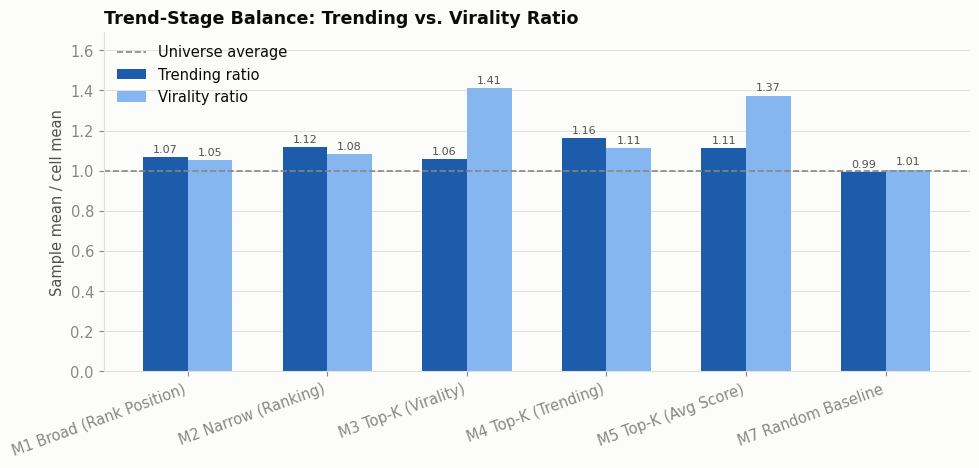

In [42]:
trend_df = scorecard[["trending_ratio", "virality_ratio"]]
x = np.arange(len(trend_df))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 4.8))
b1 = ax.bar(x - width / 2, trend_df["trending_ratio"], width, label="Trending ratio", color=BLUE_RAMP[550])
b2 = ax.bar(x + width / 2, trend_df["virality_ratio"], width, label="Virality ratio", color=BLUE_RAMP[250])
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8, color=INK_SECONDARY, xytext=(0, 2), textcoords="offset points")
ax.axhline(1.0, color=INK_MUTED, linewidth=1.2, linestyle="--", label="Universe average")
ax.set_xticks(x); ax.set_xticklabels(trend_df.index, rotation=20, ha="right")
ax.set_ylabel("Sample mean / cell mean")
ax.set_title("Trend-Stage Balance: Trending vs. Virality Ratio", loc="left", fontweight="bold")
ax.set_ylim(0, max(trend_df.values.max(), 1.0) * 1.2)
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [43]:
gap = (trend_df["virality_ratio"] - trend_df["trending_ratio"]).drop("M7 Random Baseline")
most_virality_leaning = gap.idxmax()
most_trending_leaning = gap.idxmin()
insight(
    f"**{most_virality_leaning}** skews furthest toward virality over trending (virality "
    f"{trend_df.loc[most_virality_leaning, 'virality_ratio']:.2f} vs trending "
    f"{trend_df.loc[most_virality_leaning, 'trending_ratio']:.2f}), while **{most_trending_leaning}** skews the "
    f"opposite way. M7 Random sits at trending={trend_df.loc['M7 Random Baseline', 'trending_ratio']:.2f} / "
    f"virality={trend_df.loc['M7 Random Baseline', 'virality_ratio']:.2f} by definition - the reference point "
    "every other method should be compared against, not 1.0 in the abstract."
)

**Insight.** **M3 Top-K (Virality)** skews furthest toward virality over trending (virality 1.41 vs trending 1.06), while **M4 Top-K (Trending)** skews the opposite way. M7 Random sits at trending=0.99 / virality=1.01 by definition - the reference point every other method should be compared against, not 1.0 in the abstract.

## 22. Long-Tail / Novelty Coverage

Share of selected videos whose best in-cell hashtag sits outside the top
50th percentile of its own category (i.e. the method reached beyond the
most obvious hashtags).

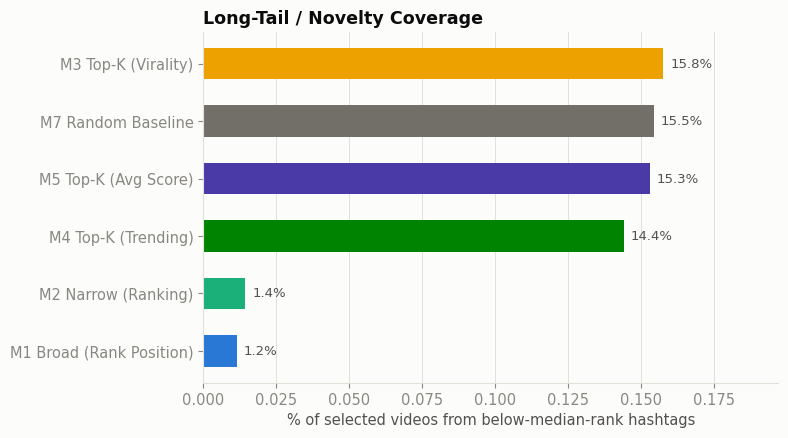

In [44]:
lt = scorecard["long_tail_coverage"].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [METHOD_COLOR[m] for m in lt.index]
bars = ax.barh(lt.index[::-1], lt.values[::-1], color=colors[::-1], height=0.55)
for bar, v in zip(bars, lt.values[::-1]):
    ax.annotate(f"{v:.1%}", (bar.get_width(), bar.get_y() + bar.get_height() / 2), va="center", ha="left",
                fontsize=9.5, color=INK_SECONDARY, xytext=(5, 0), textcoords="offset points")
ax.set_xlabel("% of selected videos from below-median-rank hashtags")
ax.set_title("Long-Tail / Novelty Coverage", loc="left", fontweight="bold")
ax.set_xlim(0, max(lt.values) * 1.25)
ax.grid(axis="x", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [45]:
insight(
    f"M1 and M2 reach far less into the long tail ({lt['M1 Broad (Rank Position)']:.1%} and "
    f"{lt['M2 Narrow (Ranking)']:.1%}) than Random ({lt['M7 Random Baseline']:.1%}) - expected, since both "
    "explicitly chase top-ranked hashtags by design. The M3-M5 top-K-per-hashtag methods all sit at or above "
    "Random, meaning ranking by video-level score still incidentally surfaces below-median hashtags that pure "
    "popularity ranking (M1/M2) misses entirely."
)

**Insight.** M1 and M2 reach far less into the long tail (1.2% and 1.4%) than Random (15.5%) - expected, since both explicitly chase top-ranked hashtags by design. The M3-M5 top-K-per-hashtag methods all sit at or above Random, meaning ranking by video-level score still incidentally surfaces below-median hashtags that pure popularity ranking (M1/M2) misses entirely.

## 23. Observations

These are descriptive read-outs of the backtest above, **not a final
recommendation** - per the proposal's scope, method selection is deferred
to a later review with the data & marketing teams.

- The quota mechanics work as designed: `country_balance` and
  `beauty_share_realized` in Section 11 are near-identical across all 6
  methods, confirming the 8-cell allocation is applied consistently
  regardless of which within-cell method is used.
- The macro-averaged radar (Section 12), its Beauty/Non-Beauty facets
  (Section 13), and the per-metric ranking bars - pooled (Section 14),
  Beauty-only (Section 15), and Non-Beauty-only (Section 16) - should be
  read together: the bars give the exact rank the radar's overlapping lines
  can obscure, and a method's overall rank can differ once the BPC split is
  isolated, given Beauty's structurally smaller category and hashtag
  universe.
- The method-family coloring in Section 17 makes explicit what shows up
  repeatedly in Sections 14-16: top-K-per-hashtag methods (M3-M5) beat
  extract-all-hashtag methods (M1-M2) on Coverage Ratio by a wide,
  consistent margin.
- The fill-rate heatmap (Section 19) is the first thing to check before
  trusting any other metric for M1/M2 in a given cell - an under-filled
  cell can make ratio-based metrics look artificially strong or weak.

## 24. Limitations

Carried over from `tiktok-sampling-strategy-v2-proposal.md` Section 8:

1. Universe is bounded by TCC's leaderboard, further bounded by hashtags
   present specifically on the 2026-06-27 snapshot.
2. ~22% of the raw universe is excluded because its hashtags don't appear
   on that pinned date - accepted as a limitation of this single-snapshot
   backtest.
3. Single-snapshot backtest - no week-over-week stability check yet.
4. The 80/20 and 50/16.67/16.67/16.67 quota is a fixed business input, not
   derived from data - a ~1.6x oversample of Beauty relative to its natural
   video-level share (50/50), much larger relative to its hashtag-population
   share (6%).
5. Video-level BPC type remains a hashtag-based proxy, not a content-verified
   label - true BPC relevance still requires the watching step this pipeline
   exists to ration.
6. `trending_score` / `virality_score` definitions are not fully known from
   TCC's side; treated as cross-validated signals, not ground truth.
7. The original design also had an M6 (Top-K by `view_count`) variant,
   dropped after review - the method numbering intentionally skips M6
   rather than renumbering M7 (Random) down to M6, so labels stay stable
   against the dashboard export in Section 25.

## 25. Export for Dashboard (Tableau)

Everything above lives only in this notebook's memory. This section writes
three linked CSV tables to `data/dashboard/`, sized and shaped for a Tableau
dashboard (KPI cards, a filterable video list, and coverage-metric charts),
filterable by **method** and **country**:

| File | Grain | Rows | Purpose |
|---|---|---|---|
| `selected_videos.csv` | method x video | 12,000 (6 methods x 2,000) | The video list view; also the source for any KPI built by aggregating raw video fields (total views, avg engagement, etc.). |
| `coverage_scorecard.csv` | method x cell | 48 (6 methods x 8 cells) | Coverage-metric charts, filterable the same way as the video list. |
| `method_summary.csv` | method | 6 | Headline KPI cards - one row per method. |

Design choices carried over from the schema discussion:

- **Country is both a code and a set of boolean flags** (`country`, plus
  `is_ID`/`is_MY`/`is_PH`/`is_TH`) - the flags make quick-filter actions in
  Tableau a single boolean check rather than a string comparison.
- **`bpc_type` gets the same treatment** (`is_beauty` boolean) for the same
  reason.
- **Category is `primary_category` + `all_categories`, and hashtags are
  `primary_hashtag_name` + `all_hashtag_names`**, not exploded rows - keeps
  `selected_videos.csv` at exactly one row per (method, video), so the
  "2,000 per method" row count stays intact instead of varying by how many
  hashtags a video happens to touch. Consuming apps (e.g. a hashtag word
  cloud) explode `all_hashtag_names` on `|` themselves at read time.
- **No overlap/lift/quota-reference tables** in this pass - scope is the
  three tables above; those can be added later if the dashboard needs them.

In [46]:
import os

# Video-intrinsic attributes: the same regardless of which method selected the video.
in_cell_edges = edges[(edges["COUNTRY_CODE"] == edges["assigned_country"]) & (edges["HASHTAG_TYPE"] == edges["assigned_type"])]

primary_hashtag = best_edge.set_index("VIDEO_ID")[["HASHTAG_ID", "HASHTAG_NAME", "CATEGORY_NAME"]].rename(columns={
    "HASHTAG_ID": "primary_hashtag_id", "HASHTAG_NAME": "primary_hashtag_name", "CATEGORY_NAME": "primary_category",
})
video_all_categories = in_cell_edges.groupby("VIDEO_ID")["CATEGORY_NAME"].agg(lambda s: "|".join(sorted(set(s)))).rename("all_categories")
video_all_hashtag_names = in_cell_edges.groupby("VIDEO_ID")["HASHTAG_NAME"].agg(lambda s: "|".join(sorted(set(s)))).rename("all_hashtag_names")
video_hashtag_count = in_cell_edges.groupby("VIDEO_ID")["HASHTAG_ID"].nunique().rename("n_hashtags_in_cell")
video_best_percentile = in_cell_edges.groupby("VIDEO_ID")["rank_percentile"].min()
video_is_long_tail = (video_best_percentile > LONG_TAIL_PERCENTILE).rename("is_long_tail")

video_dashboard_attrs = (
    primary_hashtag.join([video_all_categories, video_all_hashtag_names, video_hashtag_count, video_is_long_tail])
    .reset_index()
    .rename(columns={"VIDEO_ID": "video_id"})
)
video_dashboard_attrs.head(3)

,video_id,primary_hashtag_id,primary_hashtag_name,primary_category,all_categories,all_hashtag_names,n_hashtags_in_cell,is_long_tail
0,7636108227729460511,2525444603609,skincareset,BEAUTY,BEAUTY,skincareset,1,False
1,7645513757539552526,2570444487390,buildergel,BEAUTY_SERVICES,BEAUTY_SERVICES,buildergel,1,False
2,7647319258128485646,112748863387,dryshampoo,HAIR_CARE,HAIR_CARE,dryshampoo,1,False


In [47]:
FAMILY_LABEL = {
    "M1": "Extract-all", "M2": "Extract-all",
    "M3": "Top-K per hashtag", "M4": "Top-K per hashtag", "M5": "Top-K per hashtag",
    "M7": "Random",
}

video_attrs_cols = [
    "video_id", "video_url", "uploader", "followers_count", "upload_date", "duration_sec",
    "view_count", "like_count", "comment_count", "share_count", "engagement_rate",
    "trending_score", "trending_rank", "virality_score", "virality_rank",
    "view_velocity", "views_growth_short", "views_growth_long", "reach_ratio",
]
video_attrs = video_cell[video_attrs_cols].drop_duplicates("video_id")

rows = []
for m in METHOD_KEYS:
    for cell, sel in selections_by_cell[m].items():
        c, t = cell
        topup_ids = topup_by_cell[m][cell]
        cell_label = f"{c}-{'Beauty' if t == 'BEAUTY' else 'NonBeauty'}"
        for vid in sel:
            rows.append({
                "method_key": m, "method_label": KEY_TO_LABEL[m], "method_family": FAMILY_LABEL[m],
                "country": c, "is_ID": c == "ID", "is_MY": c == "MY", "is_PH": c == "PH", "is_TH": c == "TH",
                "bpc_type": t, "is_beauty": t == "BEAUTY", "cell": cell_label,
                "video_id": vid, "is_topup": vid in topup_ids, "est_cost_rupiah": COST_PER_VIDEO,
            })

selected_videos_export = pd.DataFrame(rows)
selected_videos_export = selected_videos_export.merge(video_attrs, on="video_id", how="left")
selected_videos_export = selected_videos_export.merge(video_dashboard_attrs, on="video_id", how="left")

print(f"selected_videos_export: {selected_videos_export.shape[0]:,} rows x {selected_videos_export.shape[1]} columns")
selected_videos_export.head(3)

selected_videos_export: 12,000 rows x 39 columns


,method_key,method_label,method_family,country,is_ID,is_MY,is_PH,is_TH,bpc_type,is_beauty,cell,video_id,is_topup,est_cost_rupiah,video_url,...,trending_score,trending_rank,virality_score,virality_rank,view_velocity,views_growth_short,views_growth_long,reach_ratio,primary_hashtag_id,primary_hashtag_name,primary_category,all_categories,all_hashtag_names,n_hashtags_in_cell,is_long_tail
0,M1,M1 Broad (Rank Position),Extract-all,ID,True,False,False,False,BEAUTY,True,ID-Beauty,7652043545699781902,False,200,https://www.tiktok.com/@drgeria/video/76520435...,...,7.73,1897,3.7170,9198,247000,200,0,24.70,2002838778364,sunscreen,BEAUTY,BEAUTY,sunscreen,1,False
1,M1,M1 Broad (Rank Position),Extract-all,ID,True,False,False,False,BEAUTY,True,ID-Beauty,7653635278564855054,False,200,https://www.tiktok.com/@best.haircuts2/video/7...,...,6.80,4298,5.6884,4466,353300,6800,0,35.33,3559931279446,hairtransformation,HAIR_CARE,HAIR_CARE,hairtransformation,1,False
2,M1,M1 Broad (Rank Position),Extract-all,ID,True,False,False,False,BEAUTY,True,ID-Beauty,7649780418715159822,False,200,https://www.tiktok.com/@barbers.taking.action/...,...,3.67,12765,3.6668,9371,22900,800,0,2.29,3263184554703,mullet,HAIR_CARE,HAIR_CARE,mullet,1,False


In [48]:
coverage_scorecard_export = metrics_long.merge(
    fill_log[["method", "country", "type", "target", "selected", "fill_rate", "hashtags_touched"]],
    on=["method", "country", "type"], how="left",
)
n_hashtags_total = {cell: ce["HASHTAG_ID"].nunique() for cell, ce in cell_edges.items()}
coverage_scorecard_export["n_hashtags_in_cell"] = coverage_scorecard_export.apply(
    lambda r: n_hashtags_total[(r["country"], r["type"])], axis=1
)
coverage_scorecard_export["n_hashtags_touched"] = (
    coverage_scorecard_export["breadth_coverage"] * coverage_scorecard_export["n_hashtags_in_cell"]
).round().astype(int)

coverage_scorecard_export = coverage_scorecard_export.rename(
    columns={"method": "method_key", "type": "bpc_type", "target": "target_budget", "selected": "selected_count"}
)
coverage_scorecard_export["method_label"] = coverage_scorecard_export["method_key"].map(KEY_TO_LABEL)
coverage_scorecard_export["method_family"] = coverage_scorecard_export["method_key"].map(FAMILY_LABEL)
coverage_scorecard_export["is_beauty"] = coverage_scorecard_export["bpc_type"].eq("BEAUTY")
for cc in COUNTRIES:
    coverage_scorecard_export[f"is_{cc}"] = coverage_scorecard_export["country"] == cc

print(f"coverage_scorecard_export: {coverage_scorecard_export.shape[0]:,} rows x {coverage_scorecard_export.shape[1]} columns")
coverage_scorecard_export.head(3)

coverage_scorecard_export: 48 rows x 24 columns


,method_key,country,bpc_type,coverage_ratio,breadth_coverage,category_balance,creator_diversity,trending_ratio,virality_ratio,long_tail_coverage,cell,target_budget,selected_count,fill_rate,hashtags_touched,n_hashtags_in_cell,n_hashtags_touched,method_label,method_family,is_beauty,is_ID,is_MY,is_PH,is_TH
0,M1,ID,BEAUTY,1.741402,0.788732,0.913331,0.913123,1.037158,0.992918,0.09250,ID-Beauty,800,800,1.0,81.0,142,112,M1 Broad (Rank Position),Extract-all,True,True,False,False,False
1,M2,ID,BEAUTY,1.148321,0.725352,0.718656,0.911673,1.073595,1.003224,0.04375,ID-Beauty,800,800,1.0,76.0,142,103,M2 Narrow (Ranking),Extract-all,True,True,False,False,False
2,M3,ID,BEAUTY,2.156566,1.000000,0.864340,0.925408,0.997482,1.140765,0.24625,ID-Beauty,800,800,1.0,NaN,142,142,M3 Top-K (Virality),Top-K per hashtag,True,True,False,False,False


In [49]:
method_summary_export = summary.join(scorecard[CORE_METRICS]).join(sanity[["country_balance", "beauty_share_realized"]])
method_summary_export = method_summary_export.reset_index().rename(
    columns={"method": "method_label", "est_cost_rupiah": "est_total_cost_rupiah"}
)
label_to_key = {v: k for k, v in KEY_TO_LABEL.items()}
method_summary_export.insert(0, "method_key", method_summary_export["method_label"].map(label_to_key))
method_summary_export.insert(2, "method_family", method_summary_export["method_key"].map(FAMILY_LABEL))

print(f"method_summary_export: {method_summary_export.shape[0]:,} rows x {method_summary_export.shape[1]} columns")
method_summary_export

method_summary_export: 6 rows x 16 columns


,method_key,method_label,method_family,total_selected,overall_fill_rate,worst_cell_fill_rate,est_total_cost_rupiah,coverage_ratio,breadth_coverage,category_balance,creator_diversity,trending_ratio,virality_ratio,long_tail_coverage,country_balance,beauty_share_realized
0,M1,M1 Broad (Rank Position),Extract-all,2000,1.0,1.0,400000,6.541688,0.320895,0.619800,0.716425,1.067422,1.053813,0.011562,0.89624,0.8005
1,M2,M2 Narrow (Ranking),Extract-all,2000,1.0,1.0,400000,2.738454,0.305717,0.480023,0.700588,1.115727,1.083103,0.014364,0.89624,0.8005
2,M3,M3 Top-K (Virality),Top-K per hashtag,2000,1.0,1.0,400000,10.673426,0.784011,0.793026,0.732848,1.058055,1.409693,0.157808,0.89624,0.8005
3,M4,M4 Top-K (Trending),Top-K per hashtag,2000,1.0,1.0,400000,9.547064,0.801289,0.768795,0.730066,1.162256,1.112240,0.144175,0.89624,0.8005
4,M5,M5 Top-K (Avg Score),Top-K per hashtag,2000,1.0,1.0,400000,10.585792,0.795714,0.782597,0.731729,1.111629,1.373356,0.153134,0.89624,0.8005
5,M7,M7 Random Baseline,Random,2000,1.0,1.0,400000,5.492089,0.517398,0.724735,0.732211,0.992060,1.005553,0.154577,0.89624,0.8005


In [50]:
DASHBOARD_DIR = "../data/dashboard"
os.makedirs(DASHBOARD_DIR, exist_ok=True)

VIDEO_COLS = [
    "method_key", "method_label", "method_family",
    "country", "is_ID", "is_MY", "is_PH", "is_TH",
    "bpc_type", "is_beauty", "cell",
    "video_id", "video_url", "uploader", "followers_count",
    "upload_date", "duration_sec",
    "view_count", "like_count", "comment_count", "share_count", "engagement_rate",
    "trending_score", "trending_rank", "virality_score", "virality_rank",
    "view_velocity", "views_growth_short", "views_growth_long", "reach_ratio",
    "primary_hashtag_id", "primary_hashtag_name", "primary_category", "all_categories", "all_hashtag_names",
    "n_hashtags_in_cell", "is_topup", "is_long_tail", "est_cost_rupiah",
]
SCORECARD_COLS = [
    "method_key", "method_label", "method_family",
    "country", "is_ID", "is_MY", "is_PH", "is_TH",
    "bpc_type", "is_beauty", "cell",
    "target_budget", "selected_count", "fill_rate",
    "coverage_ratio", "breadth_coverage", "category_balance", "creator_diversity",
    "trending_ratio", "virality_ratio", "long_tail_coverage",
    "n_hashtags_in_cell", "n_hashtags_touched",
]
SUMMARY_COLS = [
    "method_key", "method_label", "method_family",
    "total_selected", "overall_fill_rate", "worst_cell_fill_rate", "est_total_cost_rupiah",
    "coverage_ratio", "breadth_coverage", "category_balance", "creator_diversity",
    "trending_ratio", "virality_ratio", "long_tail_coverage",
    "country_balance", "beauty_share_realized",
]

selected_videos_export = selected_videos_export[VIDEO_COLS]
coverage_scorecard_export = coverage_scorecard_export[SCORECARD_COLS]
method_summary_export = method_summary_export[SUMMARY_COLS]

selected_videos_export.to_csv(f"{DASHBOARD_DIR}/selected_videos.csv", index=False)
coverage_scorecard_export.to_csv(f"{DASHBOARD_DIR}/coverage_scorecard.csv", index=False)
method_summary_export.to_csv(f"{DASHBOARD_DIR}/method_summary.csv", index=False)

print(f"wrote {DASHBOARD_DIR}/selected_videos.csv     ({selected_videos_export.shape[0]:,} rows x {selected_videos_export.shape[1]} cols)")
print(f"wrote {DASHBOARD_DIR}/coverage_scorecard.csv  ({coverage_scorecard_export.shape[0]:,} rows x {coverage_scorecard_export.shape[1]} cols)")
print(f"wrote {DASHBOARD_DIR}/method_summary.csv      ({method_summary_export.shape[0]:,} rows x {method_summary_export.shape[1]} cols)")

wrote ../data/dashboard/selected_videos.csv     (12,000 rows x 39 cols)
wrote ../data/dashboard/coverage_scorecard.csv  (48 rows x 23 cols)
wrote ../data/dashboard/method_summary.csv      (6 rows x 16 cols)


In [51]:
topup_rate = selected_videos_export["is_topup"].mean()
long_tail_rate = selected_videos_export["is_long_tail"].mean()
insight(
    f"**{selected_videos_export.shape[0]:,} rows** written to `selected_videos.csv` - exactly "
    f"{len(METHOD_KEYS)} methods x {BUDGET:,} videos, confirming every method reached its full budget. "
    f"**{topup_rate:.1%}** of rows were filled via the `top_up` fallback rather than each method's primary "
    f"ranking logic, and **{long_tail_rate:.1%}** are flagged `is_long_tail`. All three files are written to "
    "`data/dashboard/`, keyed on `method_key` (+ `country`/`bpc_type` for the scorecard) so Tableau can relate "
    "them without any row-count surprises."
)

**Insight.** **12,000 rows** written to `selected_videos.csv` - exactly 6 methods x 2,000 videos, confirming every method reached its full budget. **16.6%** of rows were filled via the `top_up` fallback rather than each method's primary ranking logic, and **15.0%** are flagged `is_long_tail`. All three files are written to `data/dashboard/`, keyed on `method_key` (+ `country`/`bpc_type` for the scorecard) so Tableau can relate them without any row-count surprises.